# Neuro-Symbolic PPM - Sepsis Case (T-LEAF)

Can **symbolic temporal knowledge** make a neural **predictive process monitoring** (PPM) model better on the Sepsis event
log?

Following the PPM pipeline: `event log → prefix log → encoding → learning → validation → runtime prediction`, knowledge is injected in two ways (following litterature):

- **Logic in the loss** (T-LEAF): train with `L = L_task + λ·L_logic`. Two branches —
  *checker* (penalise directly-follows-forbidden probability mass) and *embedder*
  (the T-LEAF distance `‖q(A) − q(w_pred)‖²` over learned DFA embeddings).
- **Output refinement**: at inference, forbid illegal next activities during
  decoding.

**Two experiments** are executed at the same time:

1. **A). Next-activity prediction** (one step). Does logic help the
   single-step task?
2. **B). Whole-trace prediction** (suffix generation). When the model
   must roll out the *entire* trace and errors compound, does logic produce more accurate and more conformant traces?

First **every step on the full dataset is prepared**, then **repeats the pipeline over shrinking data
fractions** (1, 1/2, 1/4, 1/8, 1/16) to see *where in the data regime* knowledge helps.

In [1]:
%matplotlib inline
import json
import random
import sys
from dataclasses import replace
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

ROOT = Path.cwd()
while not (ROOT / "src" / "Sepsis_Case").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Data + exploratory analysis.
from src.nspm.config import ExperimentConfig, TrainingConfig
from src.nspm.data.loader import read_xes
from src.nspm.data.prefixes import (
    ActivityVocabulary, extract_traces, make_data_loader,
    make_prefix_examples, split_traces)
from src.nspm.pipeline.analysis import build_analysis_tables, summarise
from src.nspm.pipeline.run_manager import create_next_run

# Symbolic knowledge: DFA + mined LTLf precedence constraints.
from src.nspm.process.automaton import START, ProcessDFA
from src.nspm.process.ltl_constraints import mine_precedence_constraints
from src.nspm.process.graph_encoding import FeatureSpace

# Learning: logic losses, embedder, training, evaluation.
from src.nspm.learning.logic import (
    EmbeddingLogicLoss, build_allowed_mask, precedence_violation_rate)
from src.nspm.learning.embedder import HierarchicalEmbedder
from src.nspm.learning.embedder_training import EmbedderConfig, train_embedder
from src.nspm.learning.training import resolve_device, train_model
from src.nspm.learning.evaluation import evaluate_model

# Whole-trace (suffix) prediction.
from src.nspm.learning.trace_prediction import (
    evaluate_suffix_prediction, evaluate_trace_from_start)

# Visualization helpers (all data-structure plots live in the codebase).
from src.nspm.visualization import plots

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

random.seed(42); np.random.seed(42); torch.manual_seed(42)
print("Package:", ROOT / "src" / "Sepsis_Case")

Package: C:\Users\Matteo\PycharmProjects\neuro-symbolic-ppm\src\Sepsis_Case


## 1. Configuration

`FRACTIONS`: defines a learning curve over **nested** subsets of cases
(1/16 ⊂ 1/8 ⊂ … ⊂ all), so the symbolic knowledge can be judged across data
regimes

`QUICK_RUN`: shrinks data and epochs for a fast smoke run.

In [2]:
QUICK_RUN = False

FRACTIONS = [1.0, 0.5, 0.25, 0.125, 0.0625]        # all, 1/2, 1/4, 1/8, 1/16
GRID_ARCHITECTURE = "gru"                          # the embedder logic loss is costly
BASE_MAX_CASES = 200 if QUICK_RUN else None
TARGET_EPOCHS = 4 if QUICK_RUN else 30
EMBEDDER_EPOCHS = 3 if QUICK_RUN else 5
LOGIC_WEIGHT = 0.5

# Experiment B (whole-trace) controls.
PREFIX_LENGTHS = (2, 4, 8)                          # suffix-prediction starting points
TRACE_EVAL_CASES = 40 if QUICK_RUN else 150         # cap test cases for decoding speed

DATA_PATH = ROOT / "datasets/Sepsis_Case/Sepsis_Cases_Event_Log.xes"
run_paths = create_next_run(ROOT / "runs", "Sepsis_Case_TLEAF_Story")
OUTPUT_DIR, MODEL_DIR = run_paths.root, run_paths.models

config = ExperimentConfig(
    seed=42,
    training=TrainingConfig(
        epochs=TARGET_EPOCHS, device="auto", logic_weight=LOGIC_WEIGHT,
        early_stopping_patience=4, early_stopping_min_epochs=2 if QUICK_RUN else 5,
    ),
)
device = resolve_device(config.training.device)
print("Dataset  :", DATA_PATH)
print("Run dir  :", OUTPUT_DIR)
print("Device   :", device, "| QUICK_RUN:", QUICK_RUN)
print("Fractions:", FRACTIONS)

Dataset  : C:\Users\Matteo\PycharmProjects\neuro-symbolic-ppm\datasets\Sepsis_Case\Sepsis_Cases_Event_Log.xes
Run dir  : C:\Users\Matteo\PycharmProjects\neuro-symbolic-ppm\runs\Sepsis_Case_TLEAF_Story_run_7
Device   : cuda | QUICK_RUN: False
Fractions: [1.0, 0.5, 0.25, 0.125, 0.0625]


## 2. The event log

The Sepsis Cases log (1050 patient cases, 16 activities) is a real world example. We load it once, compute exploratory tables, and fix a seeded case order.

In [3]:
events = read_xes(DATA_PATH, max_cases=BASE_MAX_CASES)
tables = build_analysis_tables(events)
summary = summarise(tables, DATA_PATH)
print(json.dumps(summary, indent=2))

all_traces = extract_traces(events)
ordered_case_ids = sorted(all_traces)
random.Random(config.seed).shuffle(ordered_case_ids)
print(f"\nTotal cases available: {len(ordered_case_ids)}")
display(tables.activities.head(8))

{
  "input": "C:\\Users\\Matteo\\PycharmProjects\\neuro-symbolic-ppm\\datasets\\Sepsis_Case\\Sepsis_Cases_Event_Log.xes",
  "cases": 1050,
  "events": 15214,
  "activities": 16,
  "variants": 846,
  "groups": 26,
  "events_per_case": {
    "mean": 14.48952380952381,
    "median": 13.0,
    "min": 3,
    "max": 185
  },
  "duration_hours": {
    "mean": 683.2594277777778,
    "median": 128.24125,
    "min": 0.03388888888888889,
    "max": 10135.774722222222
  },
  "outcomes": {
    "return_er_cases": 294,
    "admission_ic_cases": 110,
    "release_cases": 782
  },
  "most_common_activity": "Leucocytes",
  "most_common_variant_cases": 35
}

Total cases available: 1050


,concept:name,count
0,Leucocytes,3383
1,CRP,3262
2,LacticAcid,1466
3,Admission NC,1182
4,ER Triage,1053
5,ER Registration,1050
6,ER Sepsis Triage,1049
7,IV Antibiotics,823


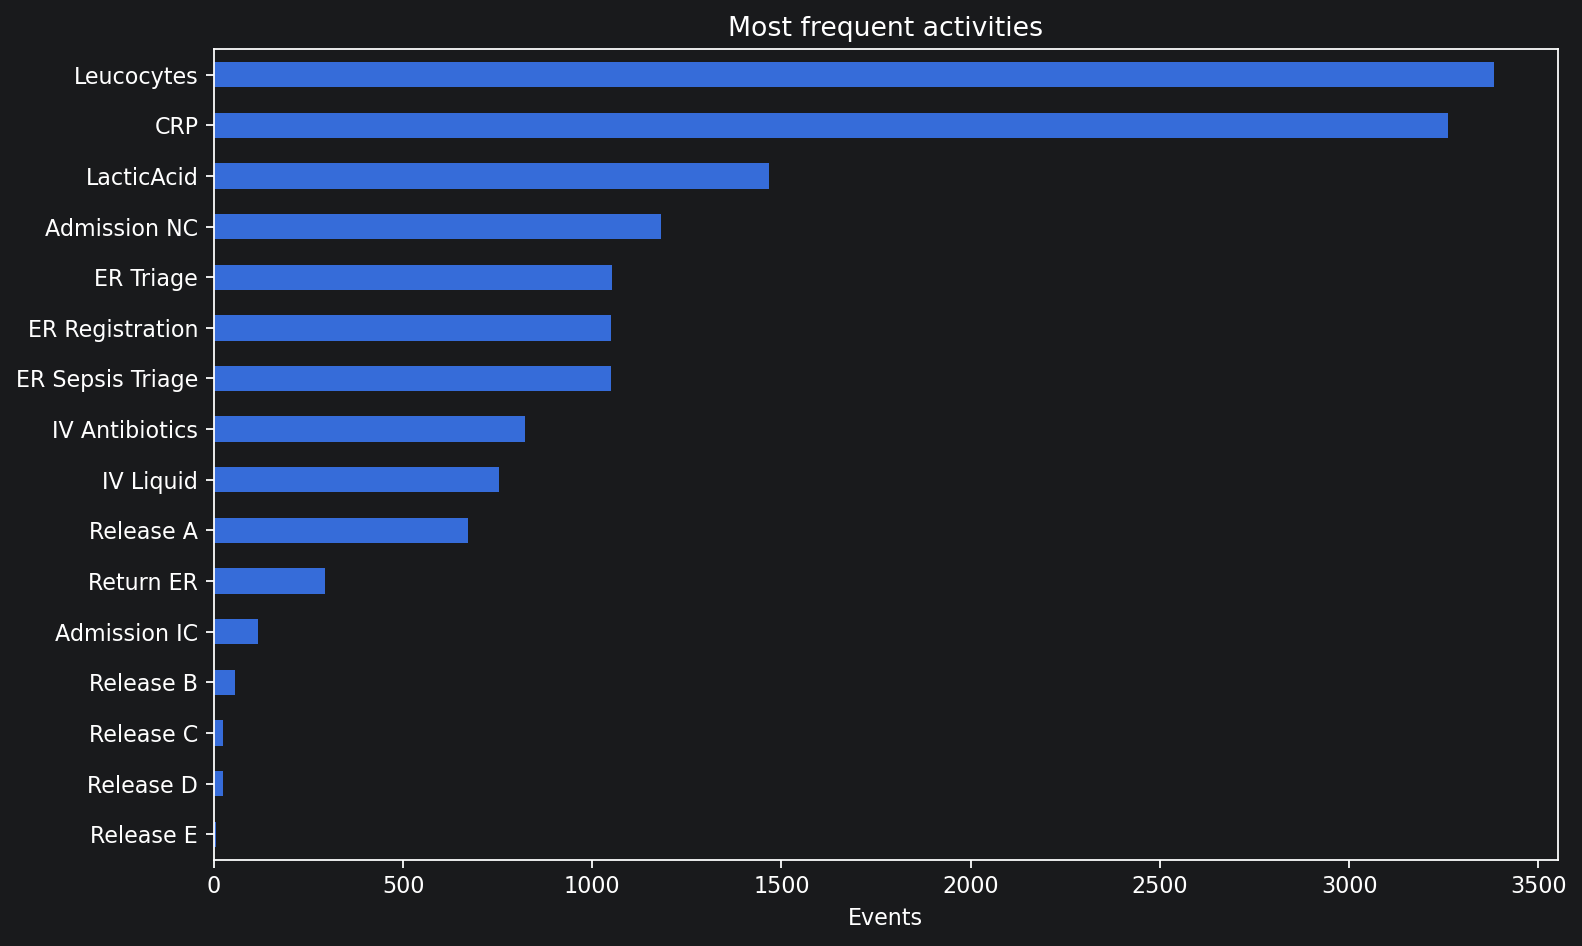

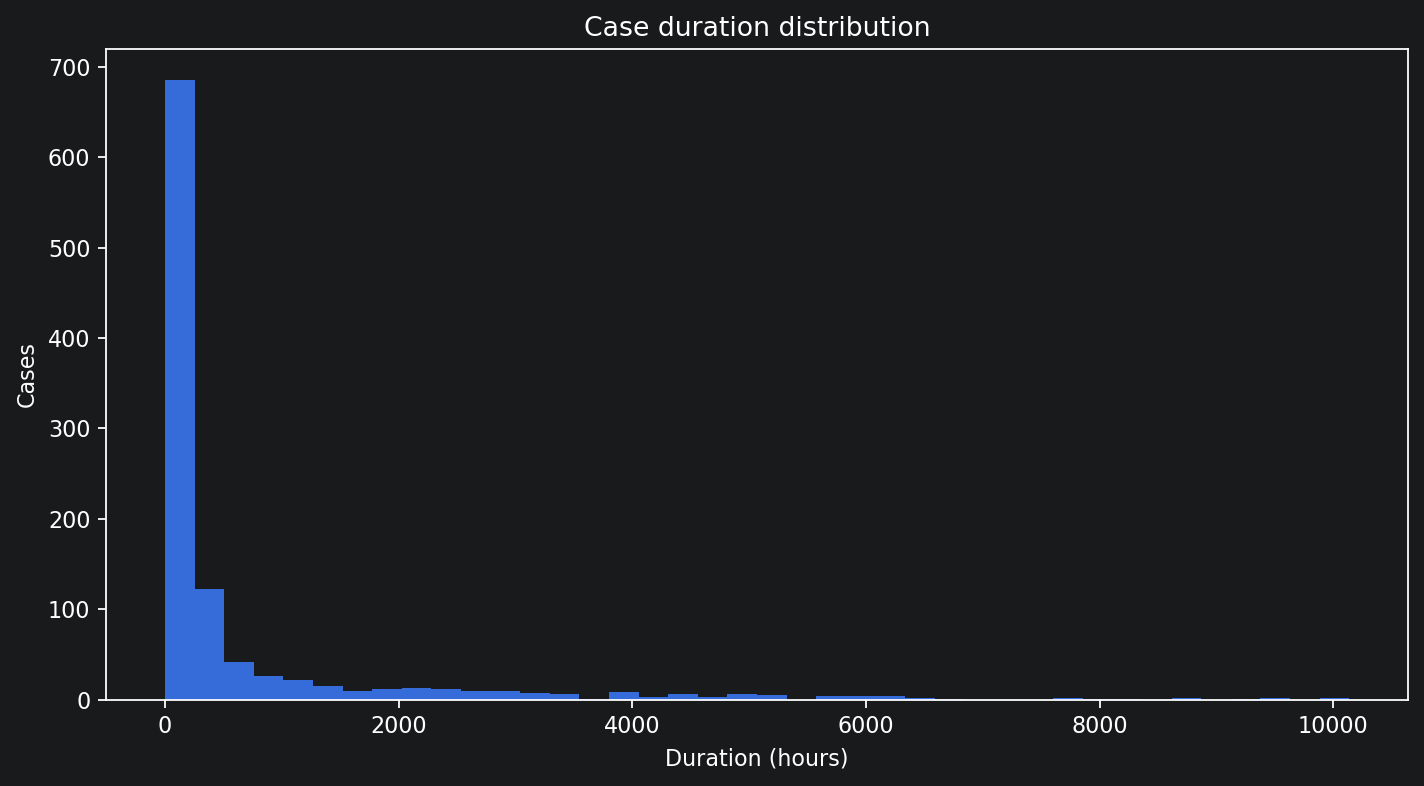

In [4]:
plots.plot_activity_frequency(events, OUTPUT_DIR / "activity_frequency.png")
plots.plot_case_durations(tables.cases, OUTPUT_DIR / "case_durations.png")
display(Image(filename=str(OUTPUT_DIR / "activity_frequency.png")))
display(Image(filename=str(OUTPUT_DIR / "case_durations.png")))

## 3. From log to a supervised learning problem

The PPM pipeline turns a log into supervised examples. We **split by case id** (so
no patient's prefixes leak across train/val/test), build the **activity
vocabulary**, and generate one **simple-index** prefix → next-activity example per
event.


In [5]:
def prepare_fraction_data(fraction, seed=config.seed):
    """Nested data subset -> case split -> vocabulary -> simple-index prefixes.

    Subsets are nested (1/16 in 1/8 in ... in all) so the fractions form a real
    learning curve; the split is by case id so prefixes of one patient never cross
    partitions (PPM book Ch. 6: no leakage)."""
    n_pool = max(3, int(round(fraction * len(ordered_case_ids))))
    sub_ids = ordered_case_ids[:n_pool]
    sub_traces = {cid: all_traces[cid] for cid in sub_ids}
    splits = split_traces(sub_traces, config.data.validation_fraction,
                          config.data.test_fraction, seed=seed)
    voc = ActivityVocabulary.from_traces(splits.train.values())
    unseen = {a for part in (splits.validation, splits.test)
              for tr in part.values() for a in tr if a not in voc.class_to_id}
    if unseen:
        voc = ActivityVocabulary.from_traces(sub_traces.values())
    examples = {n: make_prefix_examples(p, voc) for n, p in [
        ("train", splits.train), ("validation", splits.validation), ("test", splits.test)]}
    loaders = {n: make_data_loader(examples[n], voc, config.data.batch_size,
                                   shuffle=(n == "train")) for n in examples}
    return SimpleNamespace(fraction=fraction, n_pool=n_pool, sub_traces=sub_traces,
                           splits=splits, voc=voc, examples=examples, loaders=loaders)

data_full = prepare_fraction_data(1.0)
print(f"train/val/test cases : {len(data_full.splits.train)} / "
      f"{len(data_full.splits.validation)} / {len(data_full.splits.test)}")
print(f"vocabulary activities: {len(data_full.voc.activities)}")
print("prefix examples      : " + ", ".join(f"{k}={len(v)}" for k, v in data_full.examples.items()))

# One concrete simple-index example: prefix tokens -> next-activity target.
example = data_full.examples["train"][3]
print("\nExample prefix (token ids):", example.token_ids)
print("Decoded prefix           :", [data_full.voc.tokens[t] for t in example.token_ids])
print("Target next activity     :", data_full.voc.activities[example.target_id])

train/val/test cases : 735 / 157 / 158
vocabulary activities: 16
prefix examples      : train=10740, validation=2315, test=2159

Example prefix (token ids): (1, 5, 7, 6)
Decoded prefix           : ['<START>', 'ER Registration', 'ER Triage', 'ER Sepsis Triage']
Target next activity     : Leucocytes


## 4. The symbolic knowledge: a DFA and LTLf precedence rules

Two symbolic objects drive the logic:

- the empirical **directly-follows DFA** (learned from *training* traces only) —
  which activity may directly follow which; it powers the **checker** branch and
  the inference-time decoding mask;
- mined **LTLf precedence** rules `a precedes b ≡ (¬b U a) ∨ G(¬b)`, each compiled
  to a tiny 3-state DFA — the temporal knowledge the **embedder** branch learns.

We visualise all three: the process DFA, the mined rule base, and one rule's DFA.

> 📚 *Sources:* DFG/automaton & Declare/LTLf — PPM book Ch. 1, 4; LTLf→DFA and the
> DFA-as-graph the embedder consumes — T-LEAF (Xie et al., 2021), Sec. II–III.


In [6]:
def build_symbolic_layer(data):
    """Empirical directly-follows DFA + mined LTLf precedence constraints."""
    automaton = ProcessDFA.from_traces(data.splits.train.values())
    mask = build_allowed_mask(automaton, data.voc)
    n_train = len(data.splits.train)
    min_support = max(3, n_train // 10)            # adaptive to subset size
    constraints = mine_precedence_constraints(
        data.splits.train.values(), min_support=min_support,
        min_confidence=0.95, max_constraints=15)
    return SimpleNamespace(automaton=automaton, mask=mask, constraints=constraints)

sym_full = build_symbolic_layer(data_full)
print(f"DFA states/transitions : {len(sym_full.automaton.states)} / {sym_full.automaton.transition_count}")
print(f"mined precedence rules : {len(sym_full.constraints)}")
display(pd.DataFrame([
    {"earlier": c.earlier, "later": c.later, "support": c.support,
     "confidence": round(c.confidence, 3), "LTLf": c.to_ltlf()}
    for c in sym_full.constraints]))

DFA states/transitions : 18 / 128
mined precedence rules : 15


,earlier,later,support,confidence,LTLf
0,ER Sepsis Triage,IV Antibiotics,563,1.000,(!'IV Antibiotics' U 'ER Sepsis Triage') | G(!...
1,ER Triage,Admission NC,551,1.000,(!'Admission NC' U 'ER Triage') | G(!'Admissio...
2,ER Registration,Admission NC,551,1.000,(!'Admission NC' U 'ER Registration') | G(!'Ad...
3,ER Triage,Release A,465,1.000,(!'Release A' U 'ER Triage') | G(!'Release A')
4,ER Registration,Release A,465,1.000,(!'Release A' U 'ER Registration') | G(!'Relea...
5,ER Triage,Return ER,205,1.000,(!'Return ER' U 'ER Triage') | G(!'Return ER')
6,ER Registration,Return ER,205,1.000,(!'Return ER' U 'ER Registration') | G(!'Retur...
7,Admission NC,Return ER,205,1.000,(!'Return ER' U 'Admission NC') | G(!'Return ER')
8,CRP,Return ER,205,1.000,(!'Return ER' U 'CRP') | G(!'Return ER')
9,ER Triage,Admission IC,81,1.000,(!'Admission IC' U 'ER Triage') | G(!'Admissio...


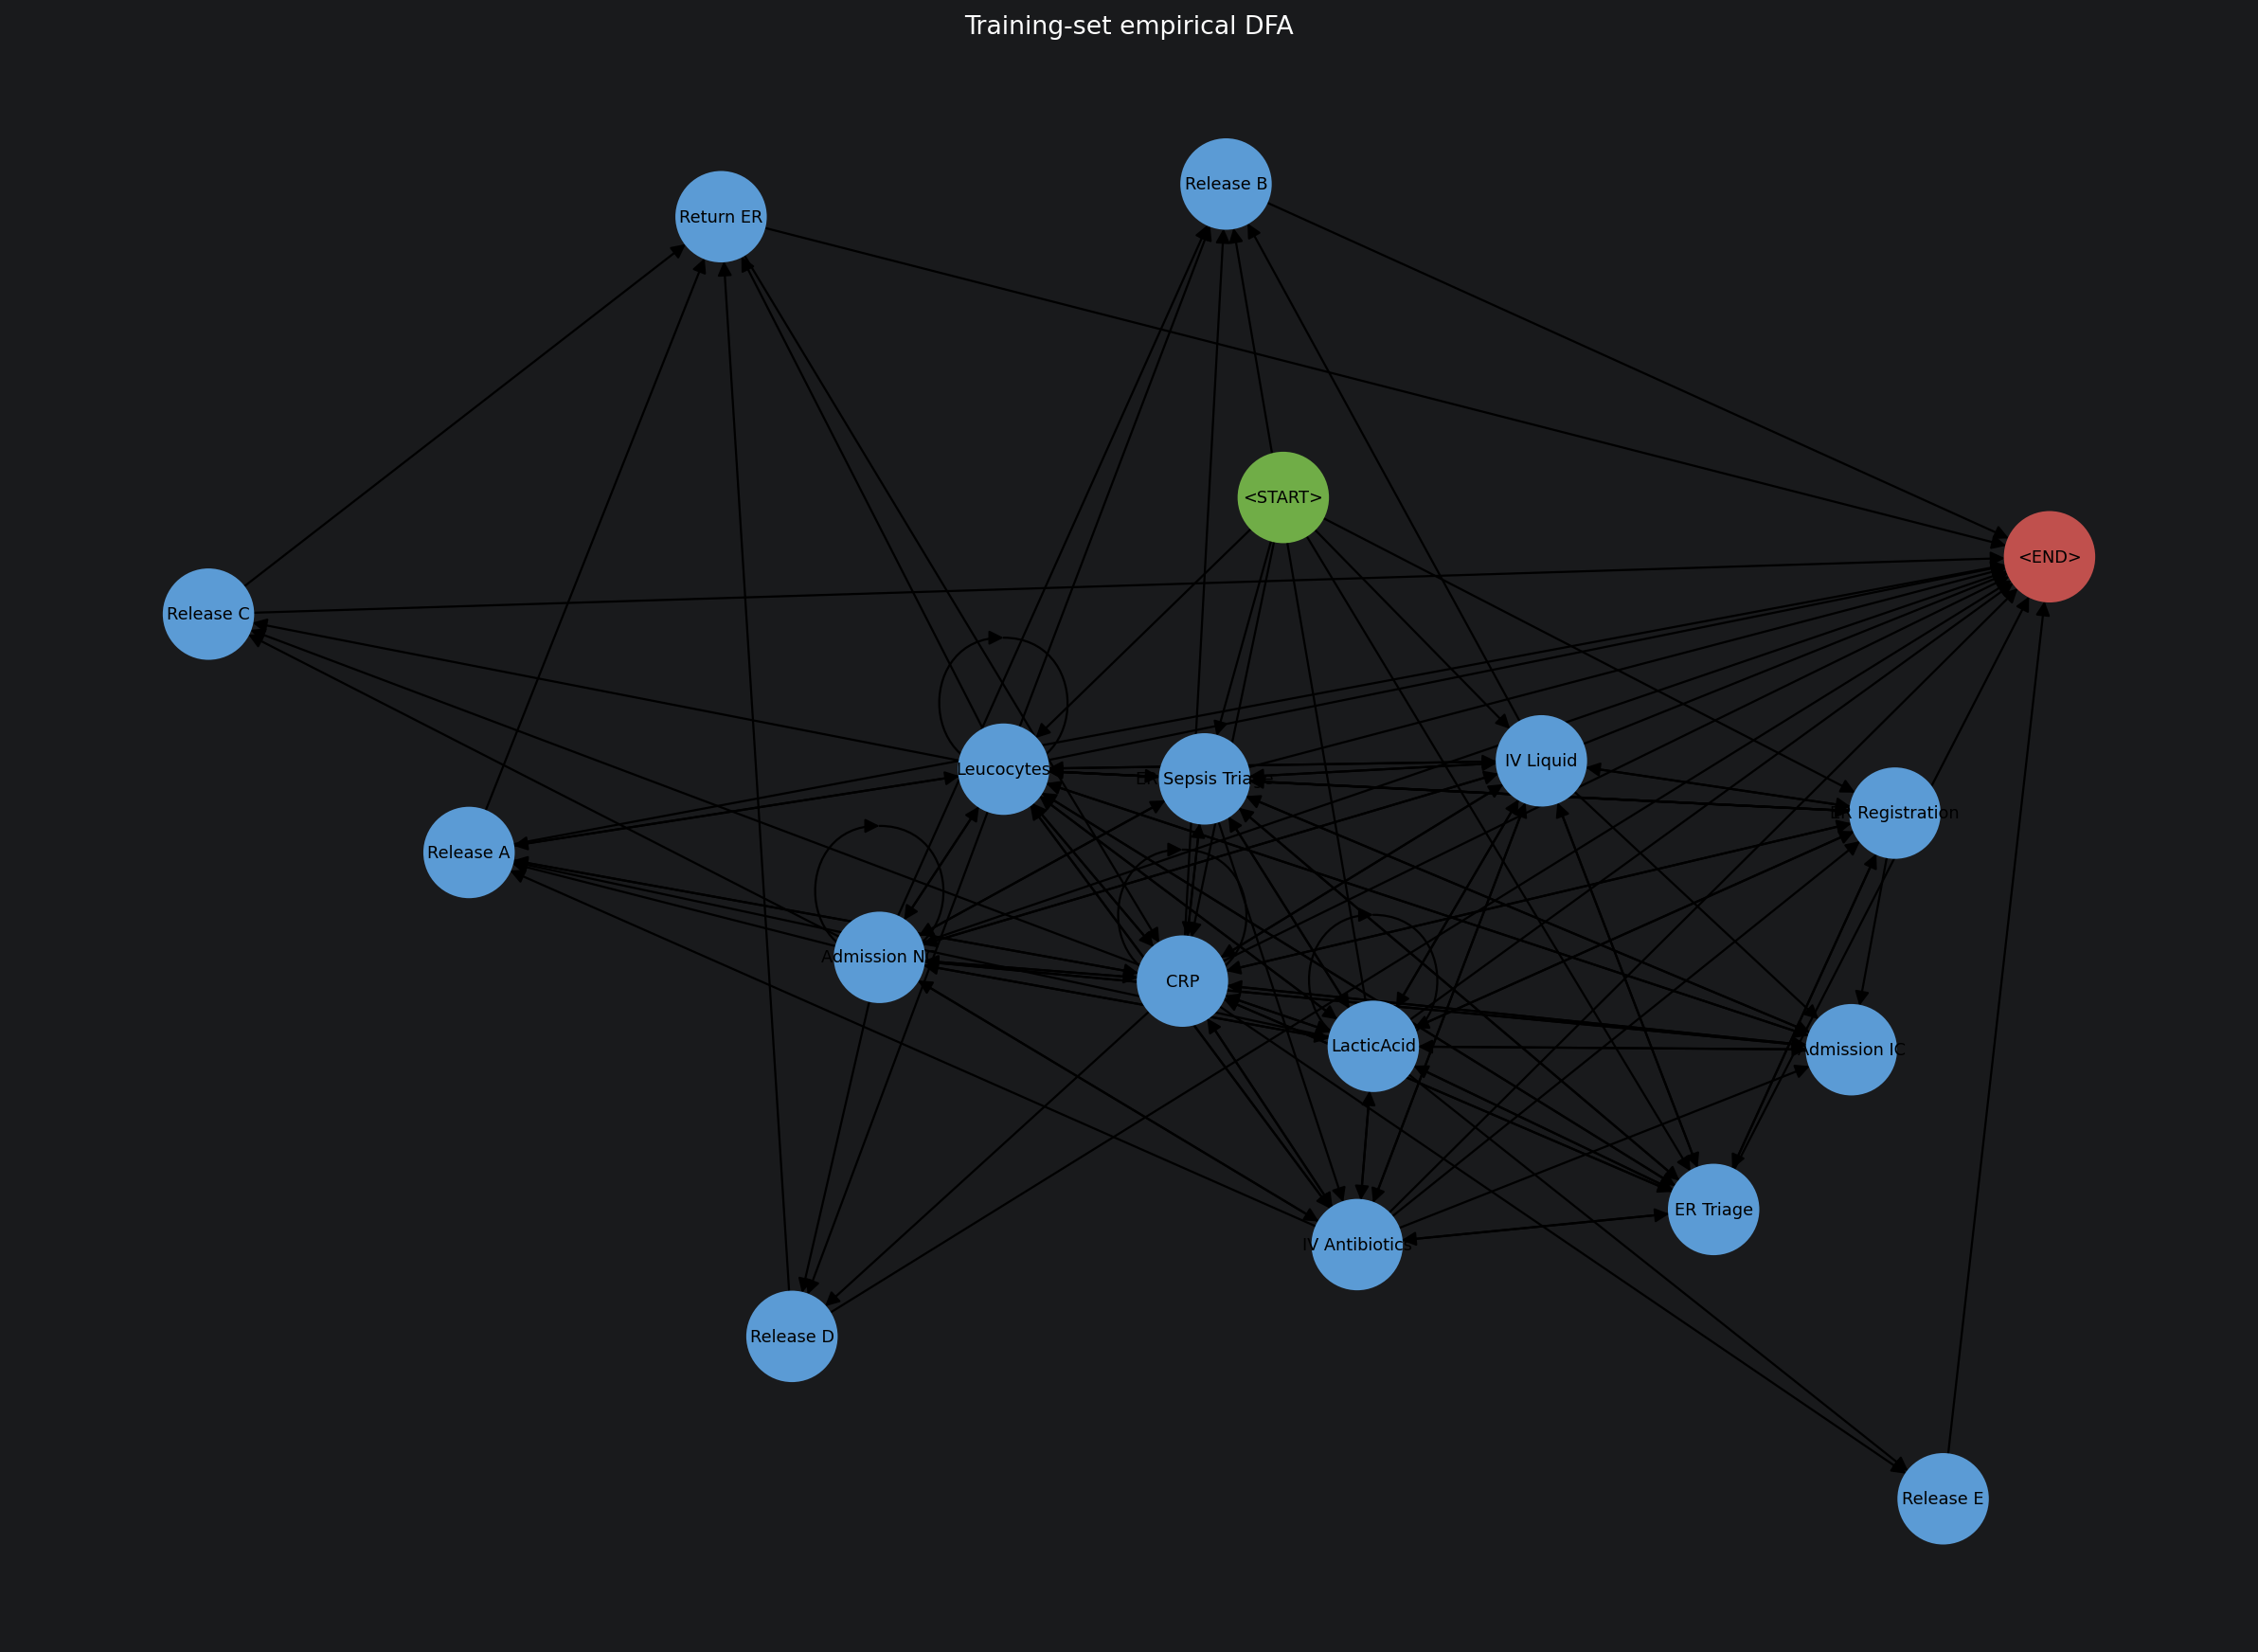

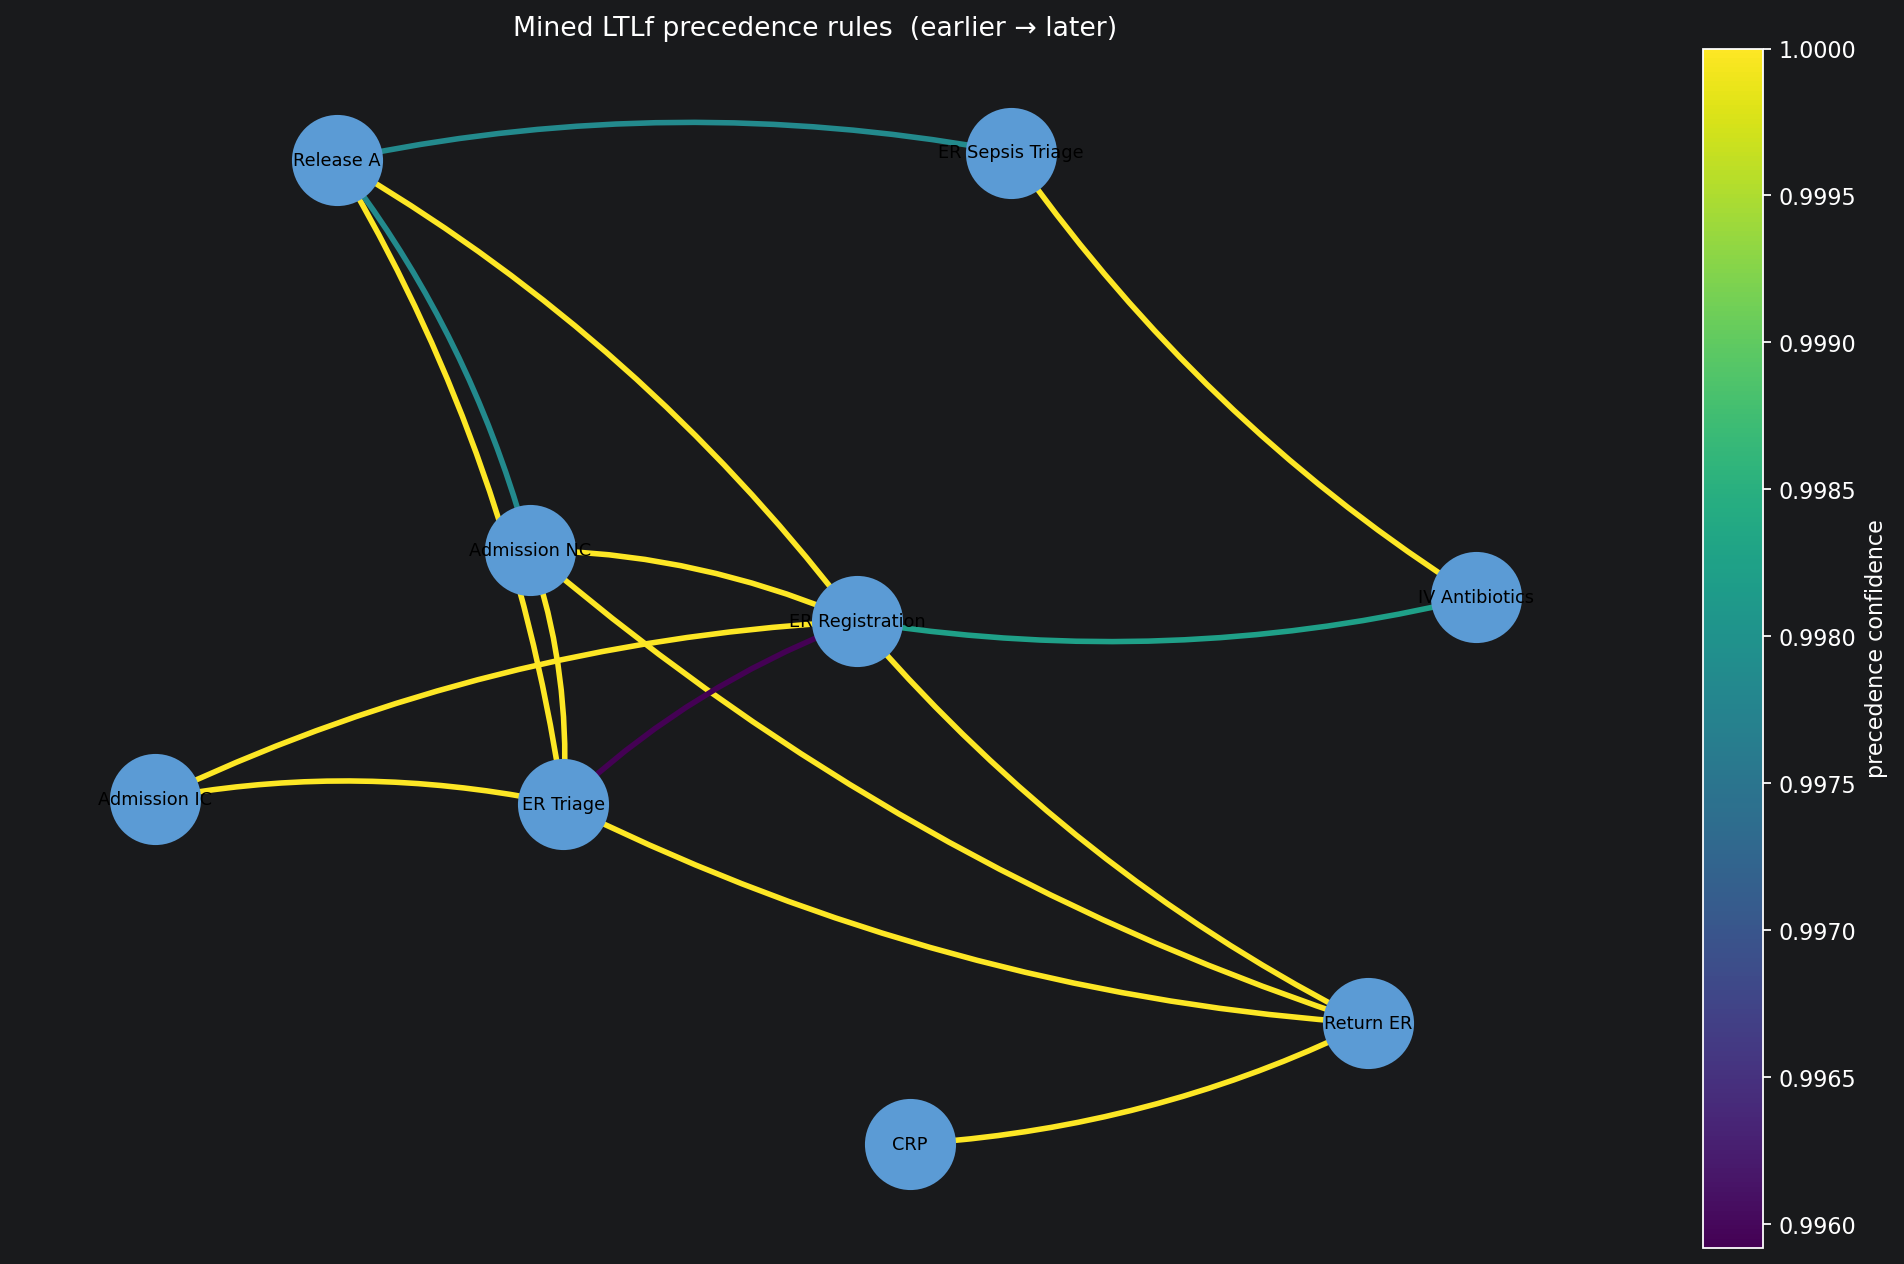

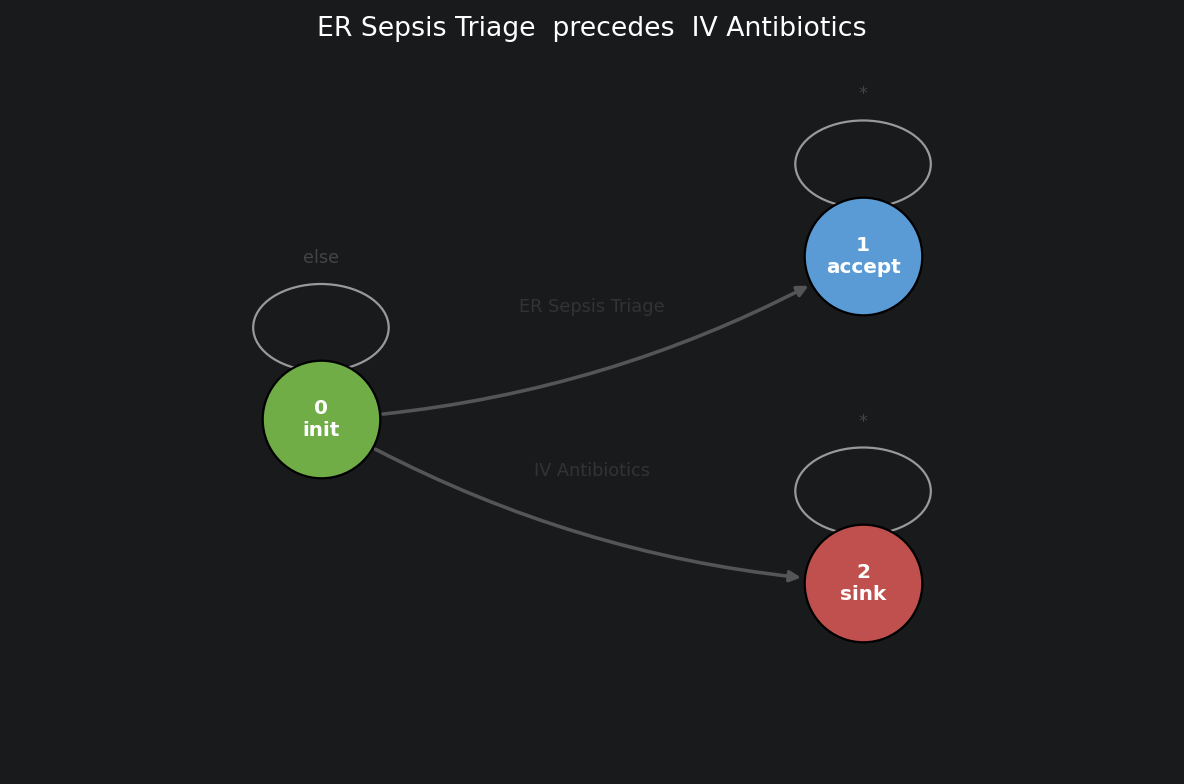

In [7]:
plots.plot_automaton(sym_full.automaton, OUTPUT_DIR / "dfa.png")
plots.plot_precedence_constraints(sym_full.constraints, OUTPUT_DIR / "constraints.png")
display(Image(filename=str(OUTPUT_DIR / "dfa.png")))
display(Image(filename=str(OUTPUT_DIR / "constraints.png")))
if sym_full.constraints:
    rule = sym_full.constraints[0]
    plots.plot_constraint_dfa(rule.to_dfa(), OUTPUT_DIR / "constraint_dfa.png",
                              title=f"{rule.earlier}  precedes  {rule.later}")
    display(Image(filename=str(OUTPUT_DIR / "constraint_dfa.png")))

## 5. Embedding the knowledge (the T-LEAF embedder)

T-LEAF embeds each constraint DFA and each predicted trace into a shared vector
space with a hierarchical GNN `q = (qe, qm)`, trained by a **triplet hinge loss**
that pulls a rule toward its satisfying traces and away from violating ones. The
frozen embedder then defines the logic loss `‖q(A) − q(w_pred)‖²` used by
Experiment A's *embedder* branch.

embedder epoch 01 loss=4.9994 acc=0.572
embedder epoch 02 loss=4.9857 acc=0.544
embedder epoch 03 loss=4.4963 acc=0.611
embedder epoch 04 loss=4.4439 acc=0.633
embedder epoch 05 loss=4.3811 acc=0.611


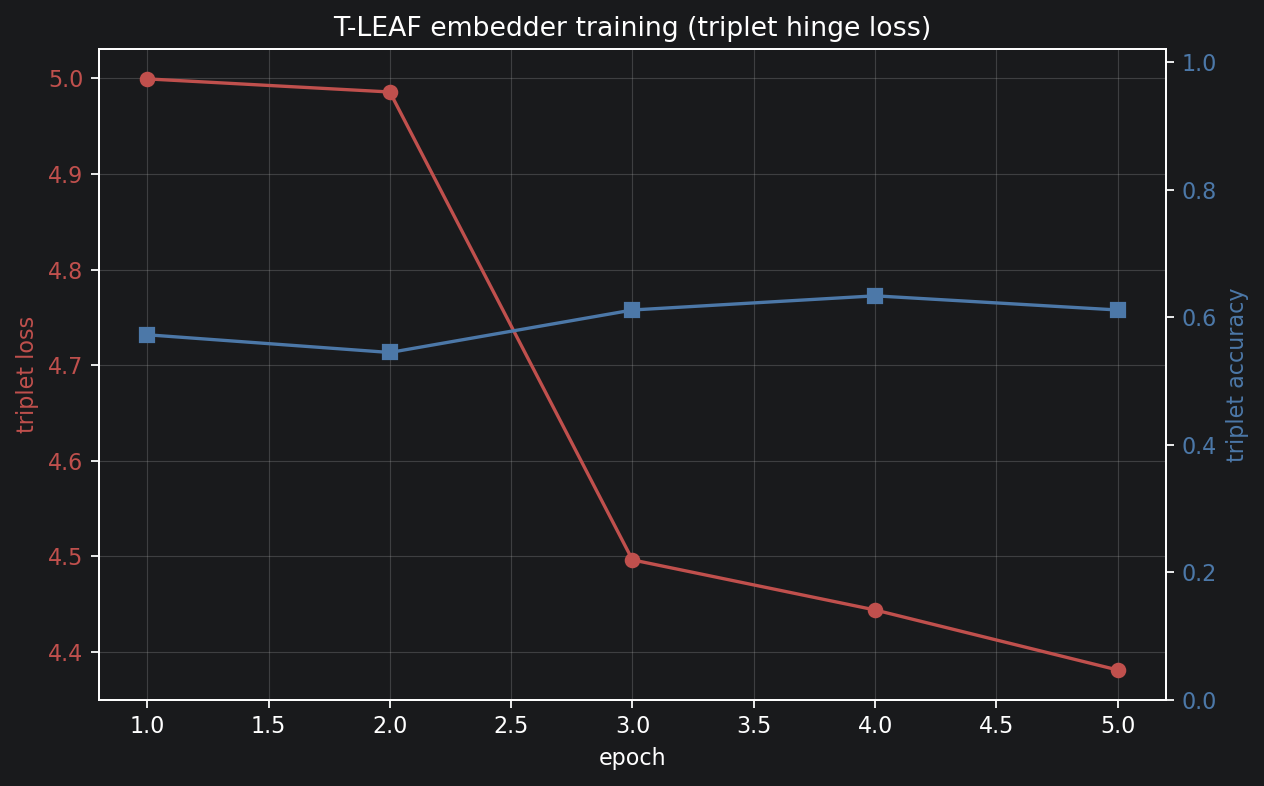

final triplet ranking accuracy: 0.611


In [8]:
def train_logic_embedder(data, sym, seed=config.seed, epochs=EMBEDDER_EPOCHS, verbose=False):
    """Train q=(qe,qm) with the triplet hinge loss; return the frozen logic loss."""
    if not sym.constraints:
        return None, None
    space = FeatureSpace.create(data.voc.activities, prop_dim=50, node_dim=100,
                                seed=seed, device=device)
    embedder = HierarchicalEmbedder(aggregation="random_walk", normalize=False,
                                    meta_layers=2).to(device)
    history = train_embedder(embedder, space, sym.constraints, data.voc.activities,
        EmbedderConfig(epochs=epochs, triplets_per_constraint=12, margin=5.0,
                       learning_rate=2e-3, seed=seed), device=device, verbose=verbose)
    emb_logic = EmbeddingLogicLoss(embedder, space, sym.constraints, data.voc,
                                   max_examples=10, max_constraints=3)
    return emb_logic, history

emb_logic_full, emb_history = train_logic_embedder(data_full, sym_full, verbose=True)
if emb_history is not None:
    plots.plot_embedder_training(emb_history, OUTPUT_DIR / "embedder_training.png")
    display(Image(filename=str(OUTPUT_DIR / "embedder_training.png")))
    print(f"final triplet ranking accuracy: {emb_history['triplet_accuracy'].iloc[-1]:.3f}")

## 6. Experiment A: next-activity prediction

We train three models with identical seed and data: **baseline** (cross-entropy
only), **checker** (+ forbidden-mass loss), **embedder** (+ T-LEAF logic loss),
then score the single-step next-activity task. Read the **embedder** on
`precedence_violation_rate` (its own knowledge) and the **checker** on
`forbidden_mass`.

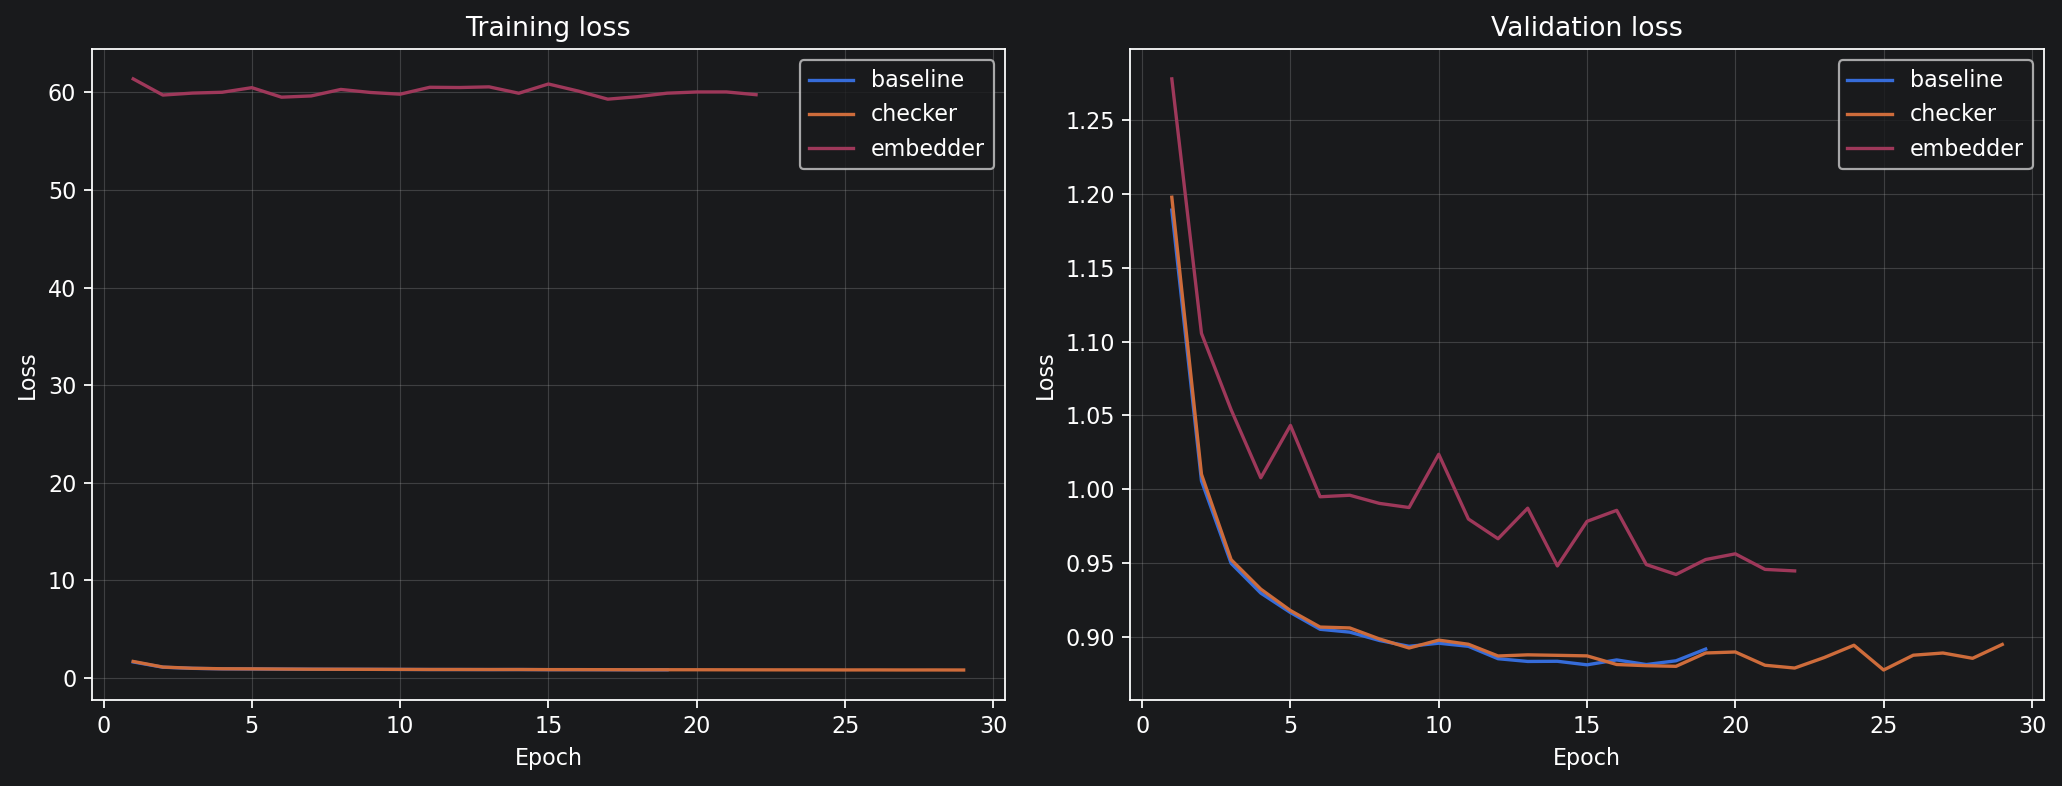

,accuracy,macro_f1,top_k_accuracy,forbidden_mass,precedence_violation_rate
logic_mode,,,,,
baseline,0.6762,0.4809,0.9352,0.0028,0.0005
checker,0.6781,0.4939,0.9324,0.0017,0.0005
embedder,0.6619,0.4734,0.9176,0.0320,0.0005


In [9]:
def train_target_models(data, sym, emb_logic, architecture=GRID_ARCHITECTURE,
                        target_epochs=TARGET_EPOCHS, seed=config.seed):
    """Train baseline / checker / embedder with identical seed and data."""
    modes = {
        "baseline": dict(use_logic=False, logic_mode="checker", embedding_logic=None),
        "checker":  dict(use_logic=True,  logic_mode="checker", embedding_logic=None),
    }
    if emb_logic is not None:
        modes["embedder"] = dict(use_logic=True, logic_mode="embedder", embedding_logic=emb_logic)
    base = replace(config, training=replace(config.training, epochs=target_epochs))
    runs = {}
    for mode, kwargs in modes.items():
        weight = 0.0 if mode == "baseline" else LOGIC_WEIGHT
        rc = replace(base, training=replace(base.training, logic_weight=weight))
        runs[mode] = train_model(architecture, data.voc, data.loaders["train"],
            data.loaders["validation"], sym.mask, rc,
            MODEL_DIR / f"f{data.fraction}_{architecture}_{mode}.pt", **kwargs)
    return runs

def evaluate_next_activity(data, sym, runs, architecture=GRID_ARCHITECTURE):
    """Experiment A metrics: single-step quality + per-branch conformance."""
    rows = []
    for mode, tr in runs.items():
        ev = evaluate_model(tr.model, data.loaders["test"], sym.mask.to(device),
                            device, top_k=config.training.top_k)
        pvr = (precedence_violation_rate(tr.model, data.loaders["test"],
               sym.constraints, data.voc, device) if sym.constraints else float("nan"))
        rows.append({"fraction": data.fraction, "architecture": architecture,
            "n_train_cases": len(data.splits.train), "n_constraints": len(sym.constraints),
            "logic_mode": mode, "accuracy": ev.accuracy, "macro_f1": ev.macro_f1,
            "top_k_accuracy": ev.top_k_accuracy, "forbidden_mass": ev.forbidden_mass,
            "violation_rate": ev.violation_rate, "precedence_violation_rate": pvr,
            "best_epoch": tr.best_epoch})
    return rows

runs_full = train_target_models(data_full, sym_full, emb_logic_full)
na_rows_full = evaluate_next_activity(data_full, sym_full, runs_full)
plots.plot_learning_curves({m: tr.history for m, tr in runs_full.items()},
                           OUTPUT_DIR / "learning_curves.png")
display(Image(filename=str(OUTPUT_DIR / "learning_curves.png")))
display(pd.DataFrame(na_rows_full).set_index("logic_mode")[
    ["accuracy", "macro_f1", "top_k_accuracy", "forbidden_mass", "precedence_violation_rate"]
    ].style.format(precision=4))

## 7. Experiment B: whole-trace prediction

Now the harder question. From a prefix, each model **autoregressively generates the
remaining trace from its own predictions**, so errors compound — the PPM
*suffix-prediction* task. We score the whole predicted trace with
**Damerau-Levenshtein similarity**, per-position accuracy, exact-match, and two
conformance measures, comparing four variants:

- `baseline`, `checker`, `embedder` — free decoding (logic only via the loss);
- `baseline+mask` — baseline decoded with DFA-forbidden activities masked out
  (**output refinement**: symbolic knowledge at inference, no retraining).

The models have no end-of-sequence token, so generation is **length-conditioned**
(as many steps as the true continuation) — this isolates ordering quality from
length prediction. Two setups: **from_start** (whole trace) and **suffix**
(continue after prefixes of length 2/4/8). Then we *look at actual predicted traces*.

In [10]:
def evaluate_whole_trace(data, sym, runs, setup, architecture=GRID_ARCHITECTURE,
                         prefix_lengths=PREFIX_LENGTHS, max_cases=TRACE_EVAL_CASES):
    """Experiment B: autoregressively generate whole traces and score them."""
    test_traces = (dict(list(data.splits.test.items())[:max_cases])
                   if max_cases else data.splits.test)

    def run_one(model, mask_arg):
        if setup == "from_start":
            return evaluate_trace_from_start(model, test_traces, data.voc, sym.automaton,
                device, allowed_mask=mask_arg, constraints=sym.constraints)
        return evaluate_suffix_prediction(model, test_traces, data.voc, sym.automaton,
            device, prefix_lengths=prefix_lengths, allowed_mask=mask_arg,
            constraints=sym.constraints)

    variants = [(mode, tr.model, None) for mode, tr in runs.items()]
    variants.append(("baseline+mask", runs["baseline"].model, sym.mask))
    rows, examples = [], {}
    for variant, model, mask_arg in variants:
        result = run_one(model, mask_arg)
        examples[variant] = result.examples
        rows.append({"fraction": data.fraction, "architecture": architecture,
            "n_train_cases": len(data.splits.train), "setup": setup,
            "variant": variant, **result.metrics()})
    return rows, examples

wt_rows_full, example_traces = [], {}
for setup in ("from_start", "suffix"):
    rows, examples = evaluate_whole_trace(data_full, sym_full, runs_full, setup)
    wt_rows_full += rows
    example_traces[setup] = examples
display(pd.DataFrame(wt_rows_full).set_index(["setup", "variant"])[
    ["dl_similarity", "activity_accuracy", "exact_match_rate",
     "dfa_violation_rate", "precedence_violation_rate"]
    ].style.format(precision=4))

Baseline — free decoding from START:


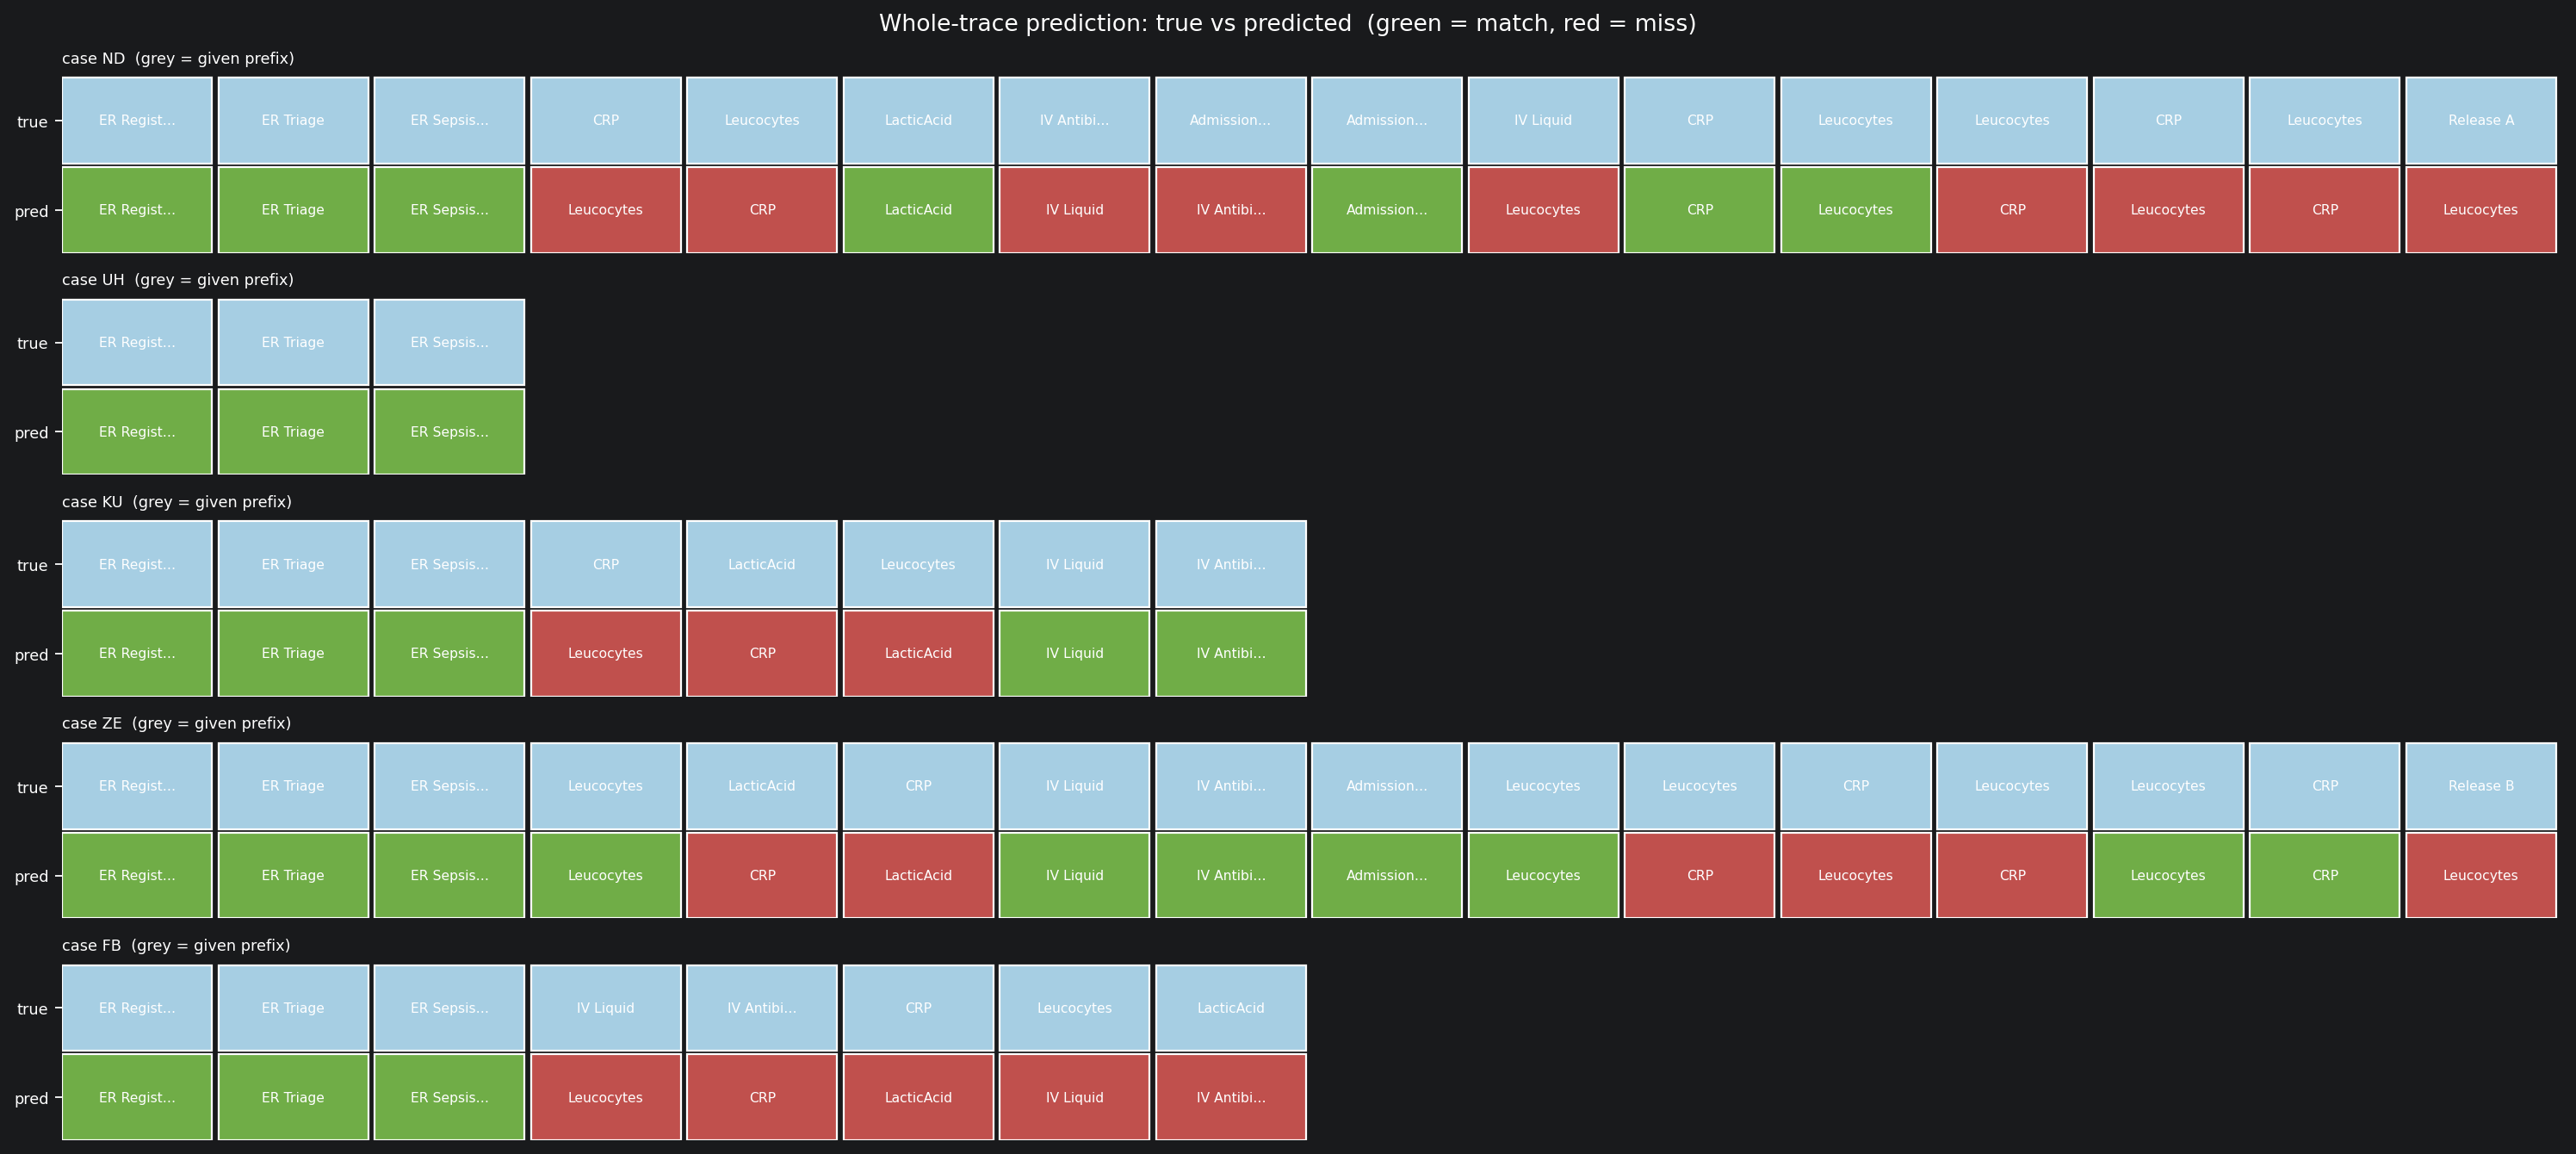

Baseline — DFA-masked decoding (output refinement):


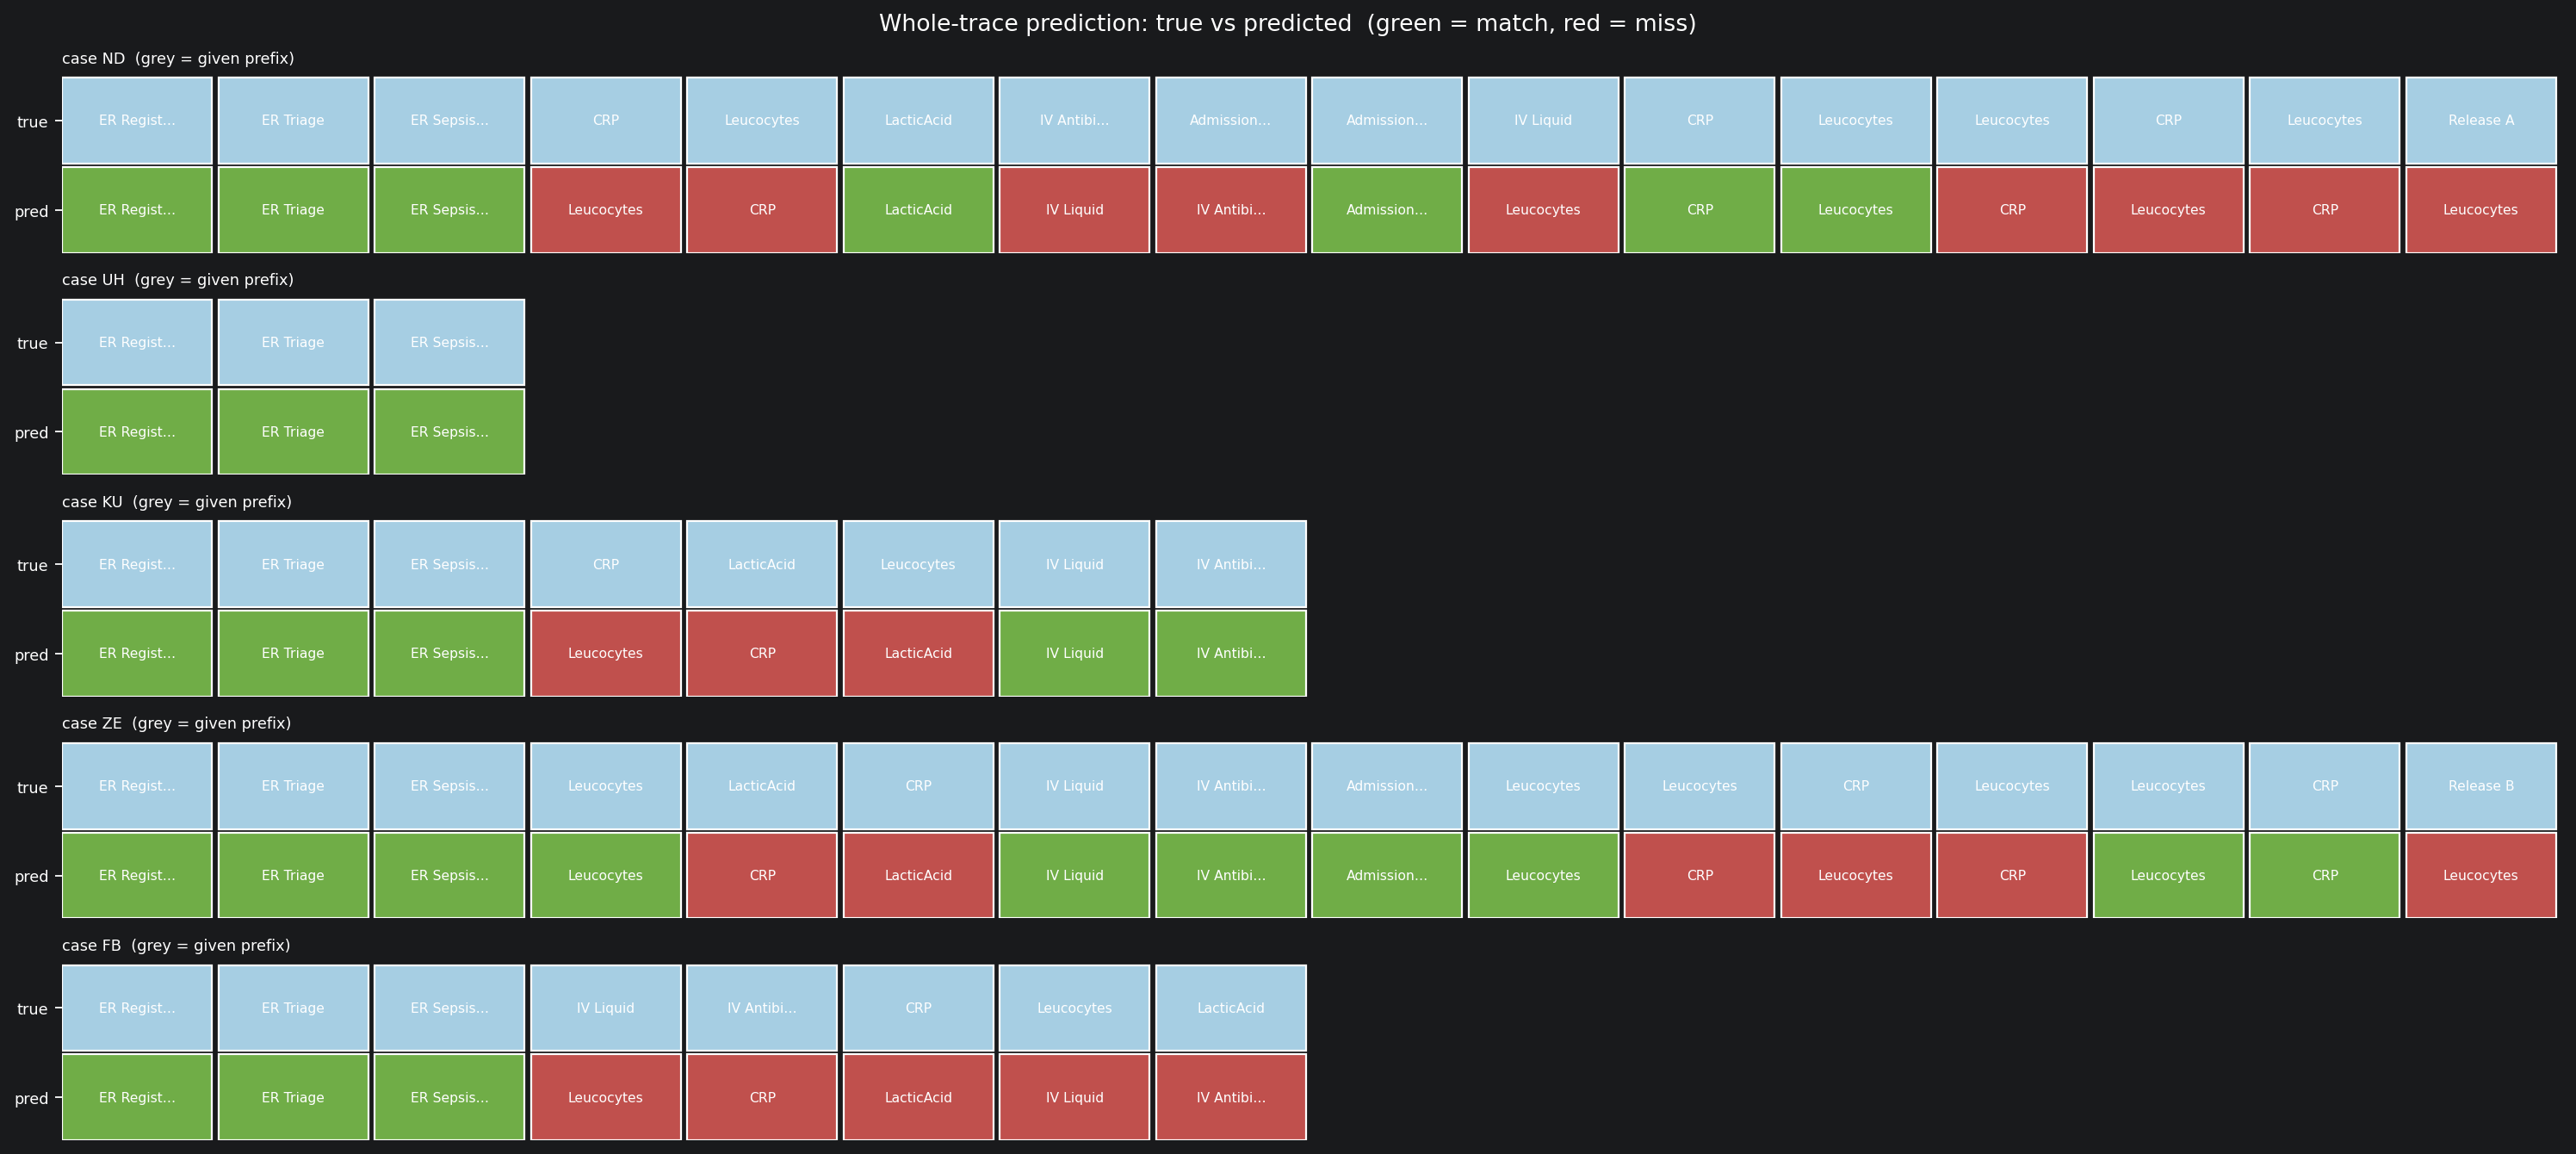

Checker — decoding (output refinement):


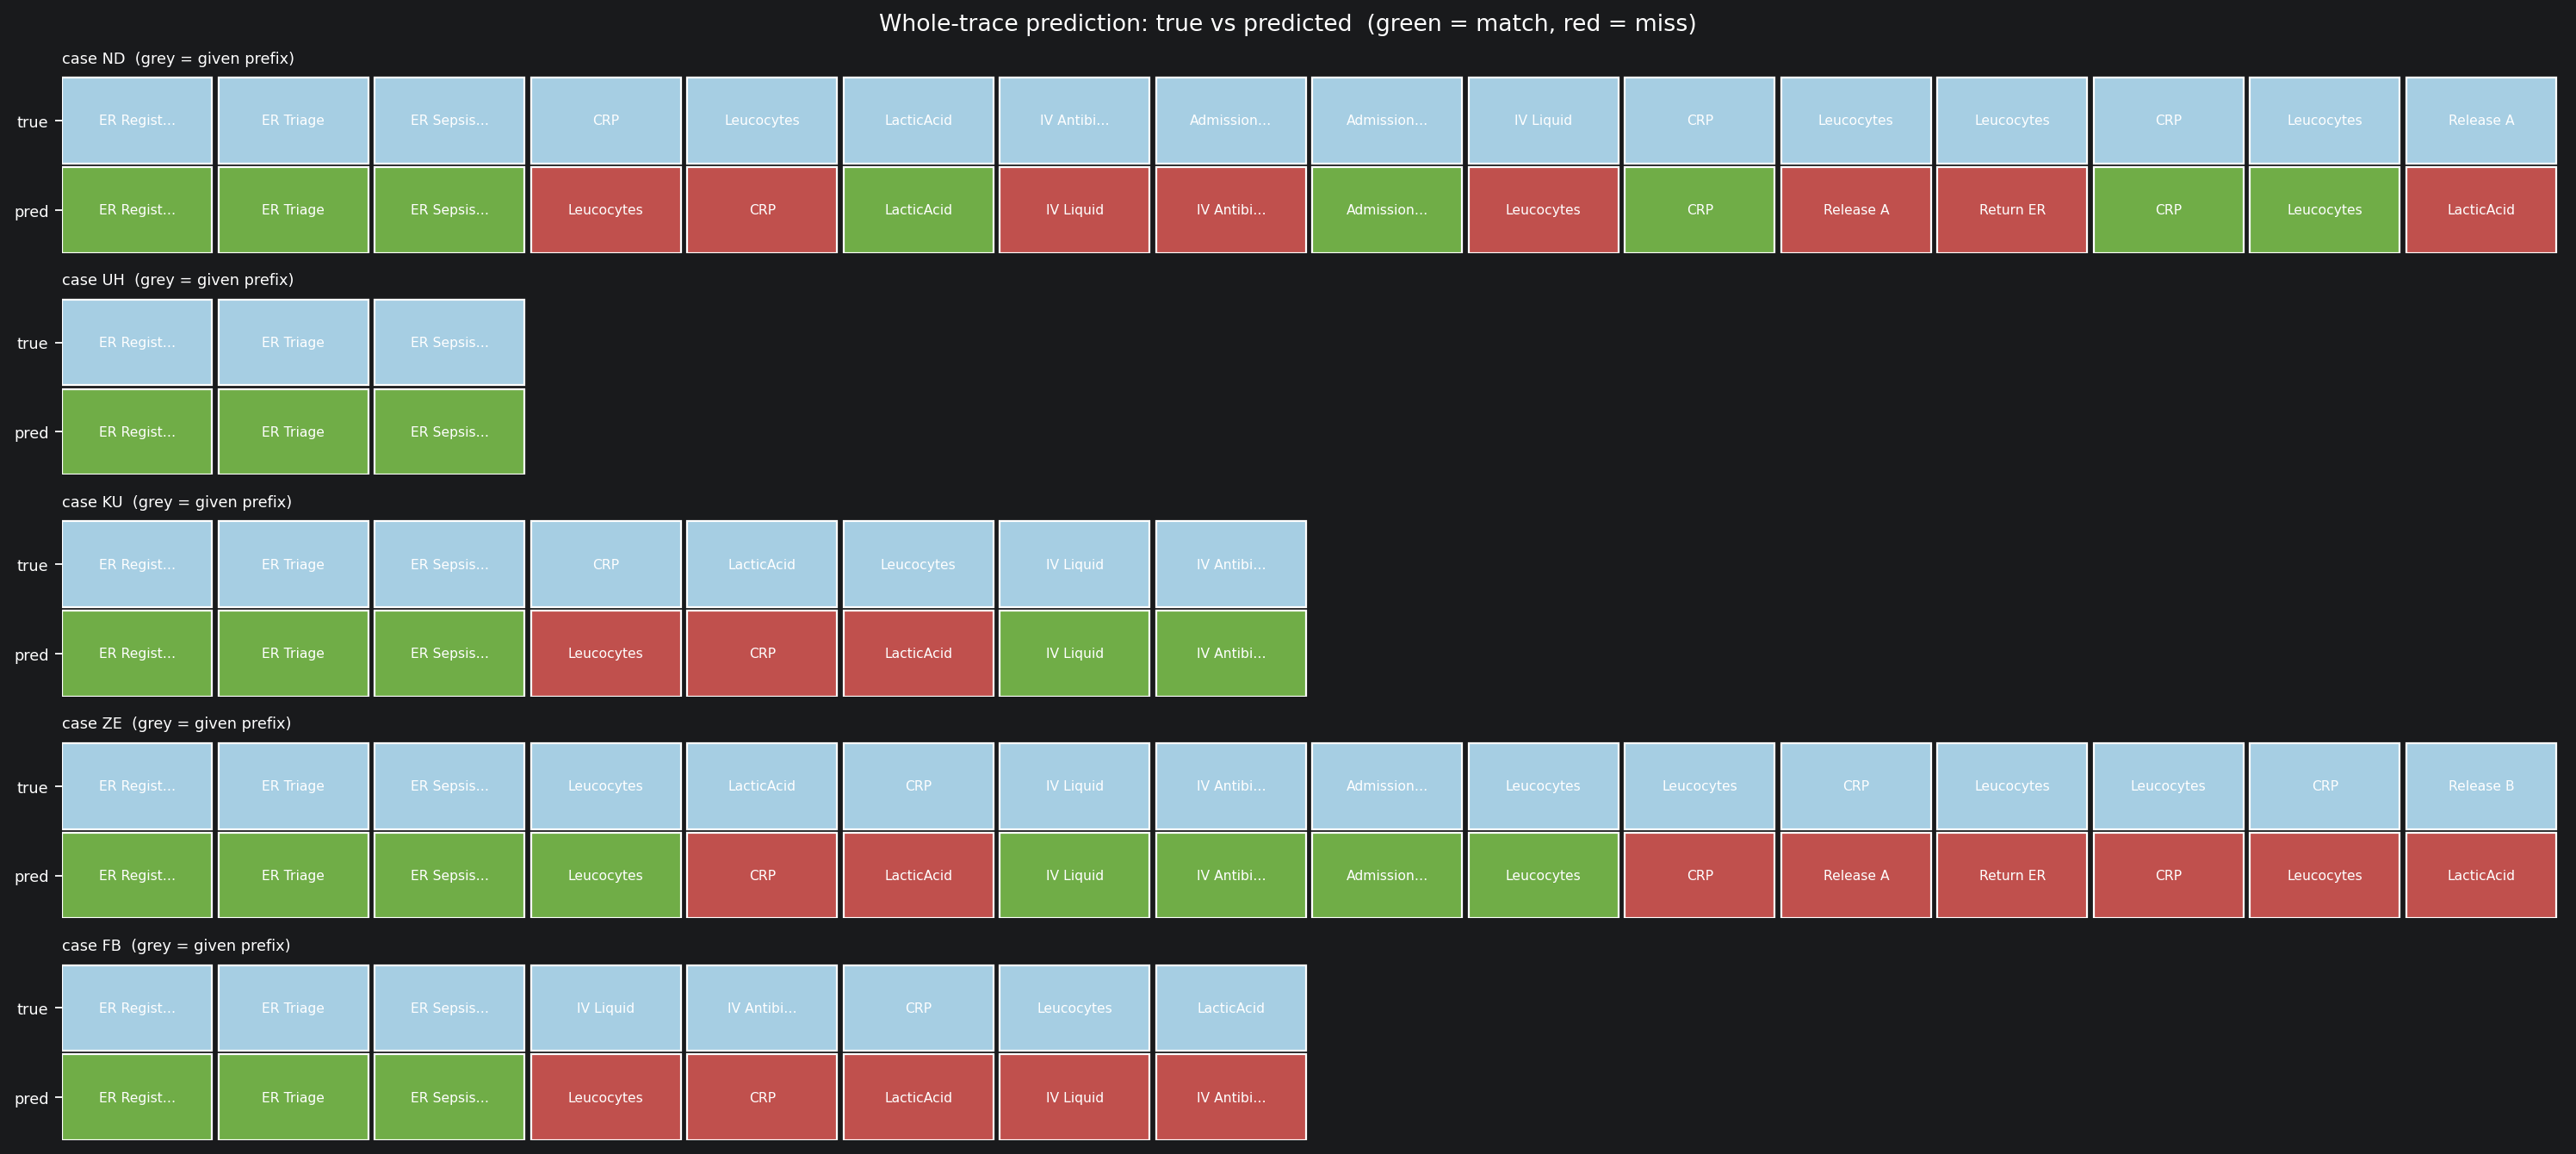

Embedder — decoding (output refinement):


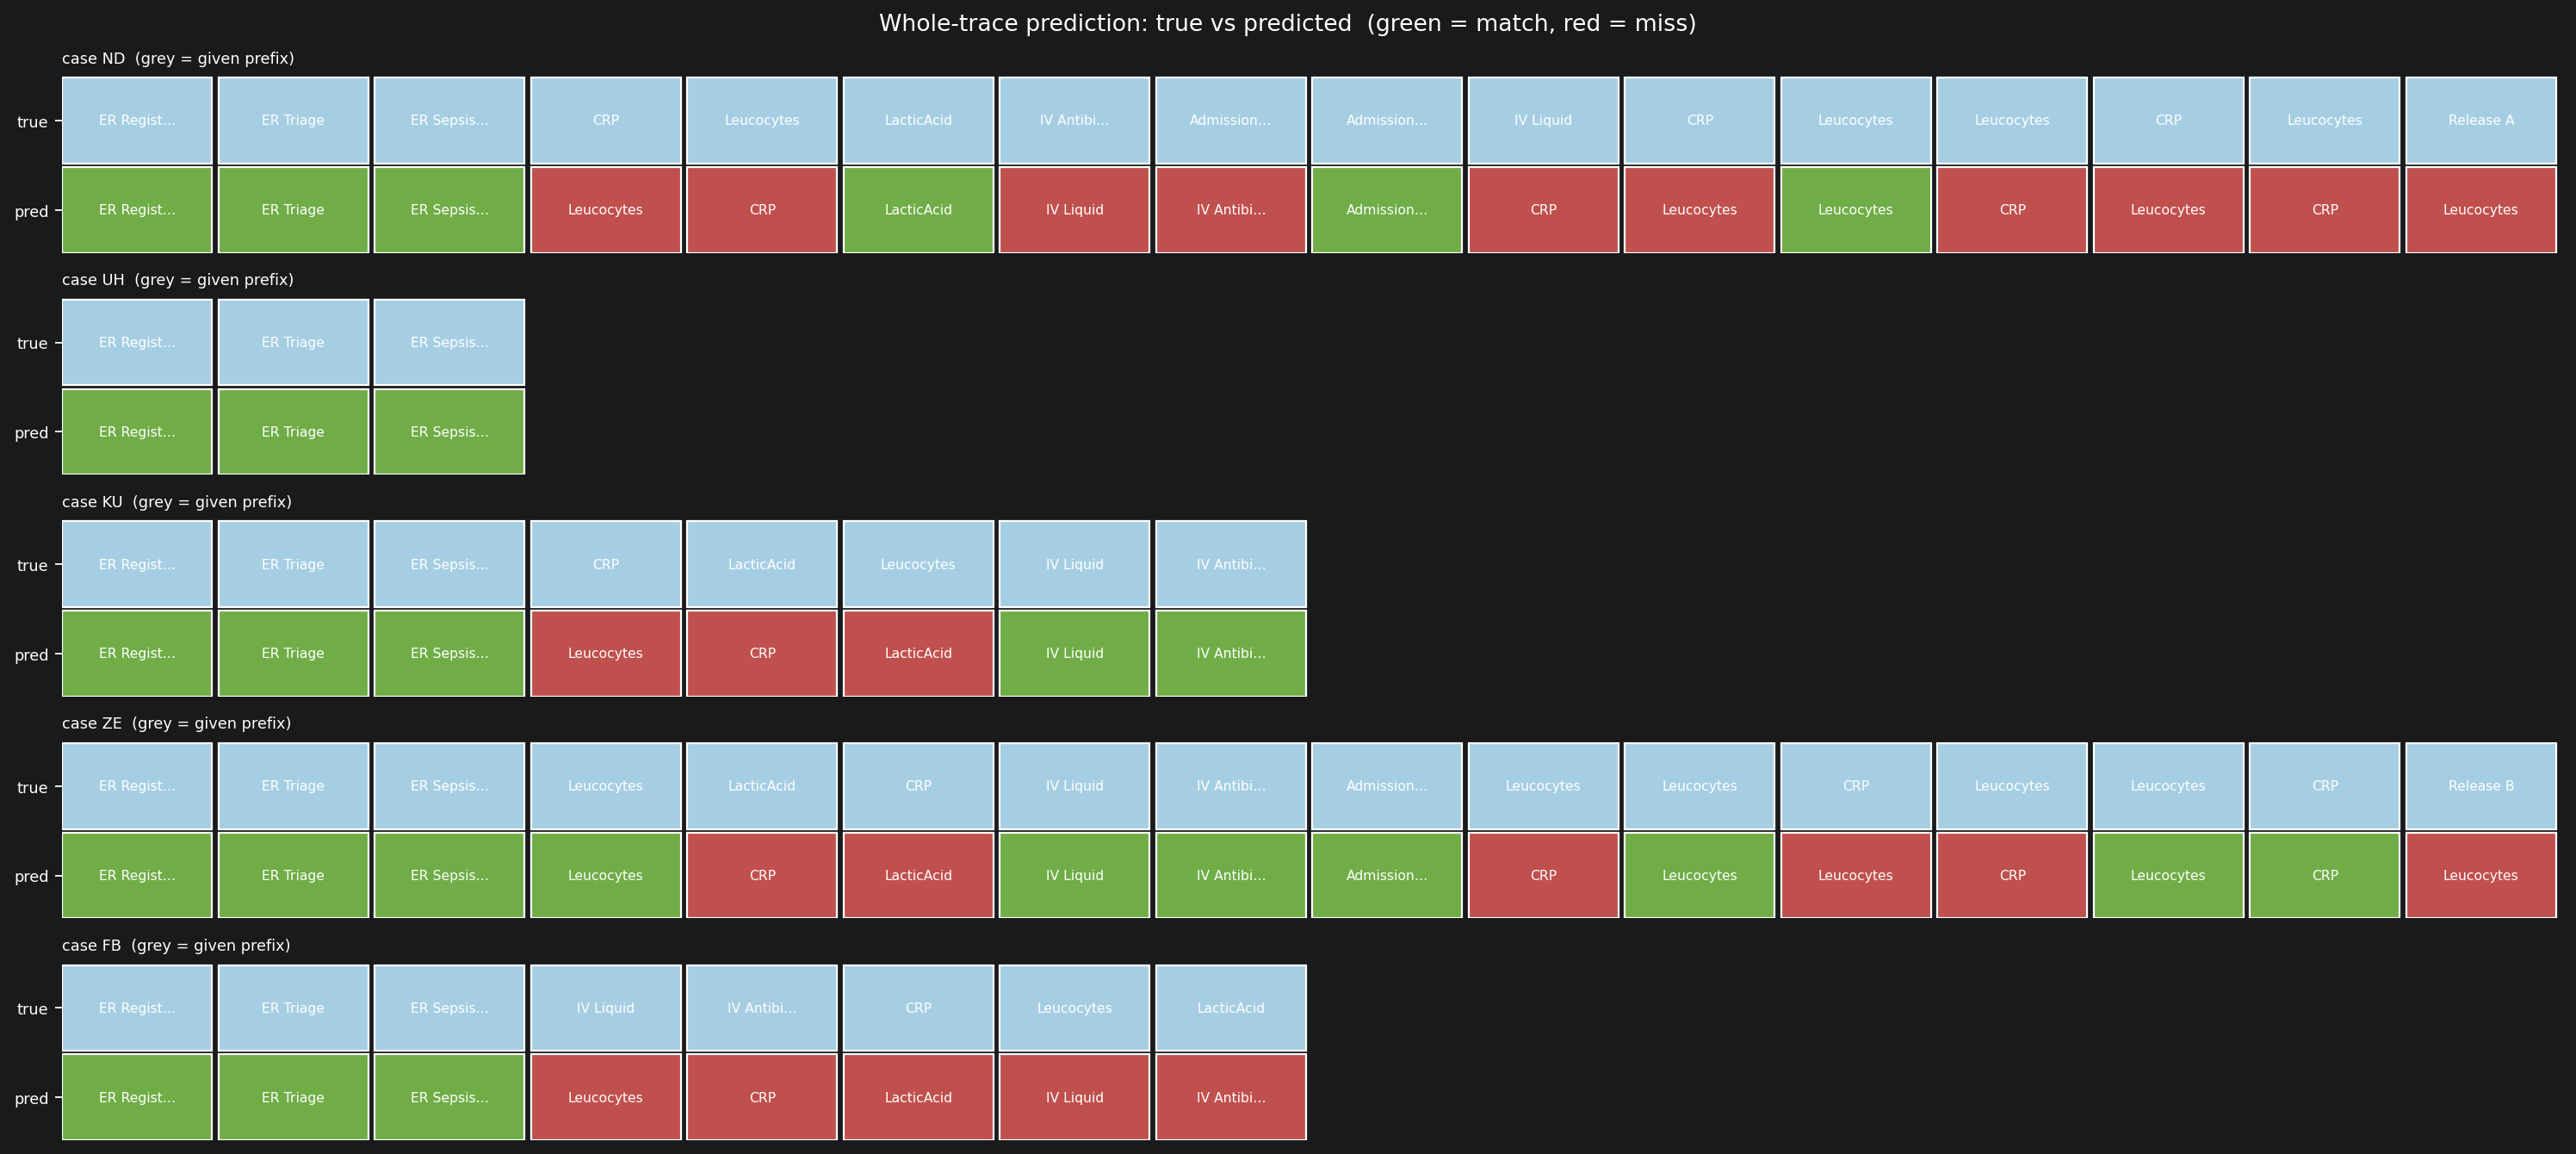

In [11]:
plots.plot_trace_comparison(example_traces["from_start"]["baseline"],
                            OUTPUT_DIR / "trace_baseline.png")
plots.plot_trace_comparison(example_traces["from_start"]["baseline+mask"],
                            OUTPUT_DIR / "trace_masked.png")
plots.plot_trace_comparison(example_traces["from_start"]["checker"],
                            OUTPUT_DIR / "trace_checker.png")
plots.plot_trace_comparison(example_traces["from_start"]["embedder"],
                            OUTPUT_DIR / "trace_embedder.png")
print("Baseline — free decoding from START:")
display(Image(filename=str(OUTPUT_DIR / "trace_baseline.png")))
print("Baseline — DFA-masked decoding (output refinement):")
display(Image(filename=str(OUTPUT_DIR / "trace_masked.png")))
print("Checker — decoding (output refinement):")
display(Image(filename=str(OUTPUT_DIR / "trace_checker.png")))
print("Embedder — decoding (output refinement):")
display(Image(filename=str(OUTPUT_DIR / "trace_embedder.png")))


## 8. The grid: repeat the whole pipeline over shrinking data

Fraction 1.0 was the detailed walkthrough. `run_fraction` bundles the exact same
steps; we now run it for 1/2 … 1/16 and collect both experiments' metrics, so we
can plot **learning curves vs training-set size**.

In [12]:
def run_fraction(fraction, seed=config.seed):
    """Full pipeline for one fraction; returns (next-activity rows, whole-trace rows)."""
    data = prepare_fraction_data(fraction, seed)
    sym = build_symbolic_layer(data)
    emb_logic, _ = train_logic_embedder(data, sym, seed)
    runs = train_target_models(data, sym, emb_logic)
    na = evaluate_next_activity(data, sym, runs)
    wt = []
    for setup in ("from_start", "suffix"):
        rows, _ = evaluate_whole_trace(data, sym, runs, setup)
        wt += rows
    return na, wt

# Fraction 1.0 came from the walkthrough above; now repeat for the smaller subsets.
na_rows, wt_rows = list(na_rows_full), list(wt_rows_full)
for fraction in FRACTIONS[1:]:
    print(f"\n===== FRACTION {fraction} =====")
    na, wt = run_fraction(fraction)
    na_rows += na; wt_rows += wt
    for r in na:
        print(f"  {r['logic_mode']:9s} n_train={r['n_train_cases']:>4} "
              f"acc={r['accuracy']:.4f} prec_viol={r['precedence_violation_rate']:.4f}")

na_grid = pd.DataFrame(na_rows); wt_grid = pd.DataFrame(wt_rows)
na_grid.to_csv(OUTPUT_DIR / "next_activity_grid.csv", index=False)
wt_grid.to_csv(OUTPUT_DIR / "whole_trace_grid.csv", index=False)
print("\nsaved grids to", OUTPUT_DIR)


===== FRACTION 0.5 =====
  baseline  n_train= 367 acc=0.6628 prec_viol=0.0000
  checker   n_train= 367 acc=0.6717 prec_viol=0.0000
  embedder  n_train= 367 acc=0.6106 prec_viol=0.0000

===== FRACTION 0.25 =====
  baseline  n_train= 183 acc=0.6427 prec_viol=0.0000
  checker   n_train= 183 acc=0.6427 prec_viol=0.0000
  embedder  n_train= 183 acc=0.6327 prec_viol=0.0000

===== FRACTION 0.125 =====
  baseline  n_train=  91 acc=0.6000 prec_viol=0.0000
  checker   n_train=  91 acc=0.5806 prec_viol=0.0032
  embedder  n_train=  91 acc=0.5903 prec_viol=0.0000

===== FRACTION 0.0625 =====
  baseline  n_train=  46 acc=0.5938 prec_viol=0.0000
  checker   n_train=  46 acc=0.6328 prec_viol=0.0000
  embedder  n_train=  46 acc=0.6094 prec_viol=0.0000

saved grids to C:\Users\Matteo\PycharmProjects\neuro-symbolic-ppm\runs\Sepsis_Case_TLEAF_Story_run_7


## 9. Experiment A: results across data regimes

Curves of conformance and accuracy vs training cases, plus the per-fraction verdict
(embedder − baseline). The recurring finding: on this log the baseline already
learns the directly-follows structure, so the **single-step** task leaves little
room for logic to help — and only when data is scarce.


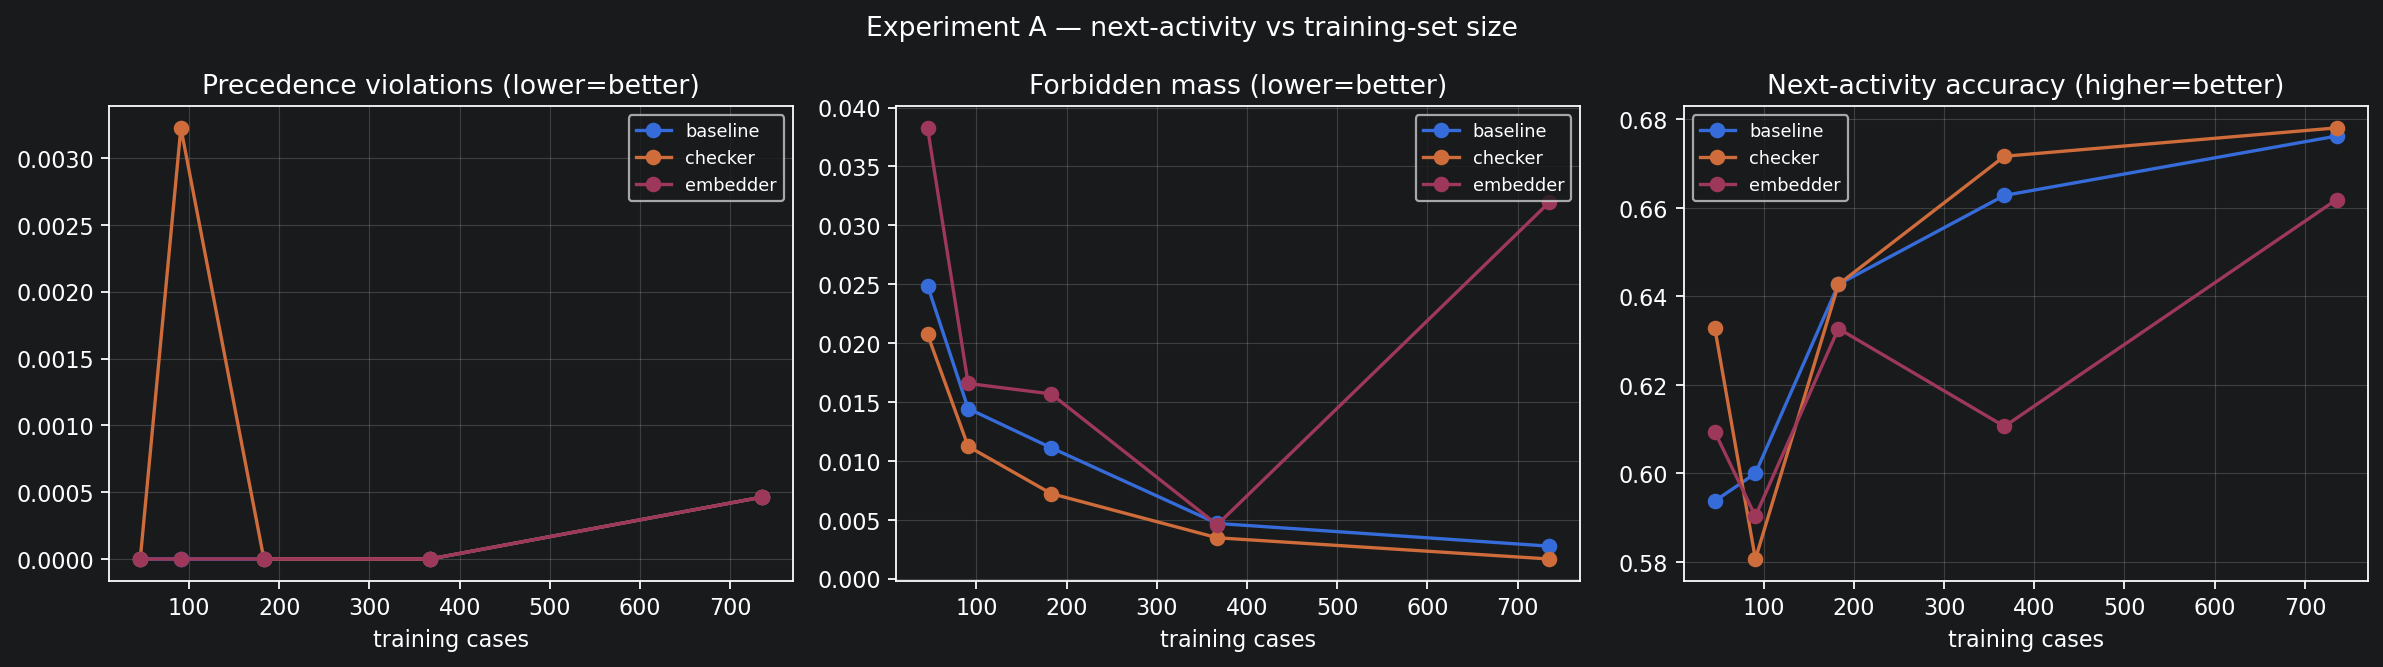

Verdict (embedder - baseline), by fraction:
  f=1.0    n_train= 735: d_acc=-0.0144  d_prec_viol=+0.00000
  f=0.5    n_train= 367: d_acc=-0.0522  d_prec_viol=+0.00000
  f=0.25   n_train= 183: d_acc=-0.0100  d_prec_viol=+0.00000
  f=0.125  n_train=  91: d_acc=-0.0097  d_prec_viol=+0.00000
  f=0.0625 n_train=  46: d_acc=+0.0156  d_prec_viol=+0.00000


In [13]:
plots.plot_fraction_curves(na_grid,
    ["precedence_violation_rate", "forbidden_mass", "accuracy"],
    OUTPUT_DIR / "expA_curves.png", mode_col="logic_mode",
    titles={"precedence_violation_rate": "Precedence violations (lower=better)",
            "forbidden_mass": "Forbidden mass (lower=better)",
            "accuracy": "Next-activity accuracy (higher=better)"},
    suptitle="Experiment A — next-activity vs training-set size")
display(Image(filename=str(OUTPUT_DIR / "expA_curves.png")))

print("Verdict (embedder - baseline), by fraction:")
for fraction in sorted(na_grid["fraction"].unique(), reverse=True):
    sub = na_grid[na_grid.fraction == fraction]
    if "embedder" not in set(sub.logic_mode):
        continue
    b = sub[sub.logic_mode == "baseline"].iloc[0]
    e = sub[sub.logic_mode == "embedder"].iloc[0]
    print(f"  f={fraction:<6} n_train={int(b.n_train_cases):>4}: "
          f"d_acc={e.accuracy - b.accuracy:+.4f}  "
          f"d_prec_viol={e.precedence_violation_rate - b.precedence_violation_rate:+.5f}")

## 10. Experiment B: results across data regimes

The whole-trace view. Watch `dfa_violation_rate`: free decoding drifts onto illegal
transitions as it rolls out, while `baseline+mask` (output refinement) is **0 by
construction** and the logic-in-loss models should sit in between. The
DL-similarity / accuracy curves then tell us whether staying conformant also makes
the *whole predicted trace* more accurate — especially as data shrinks.


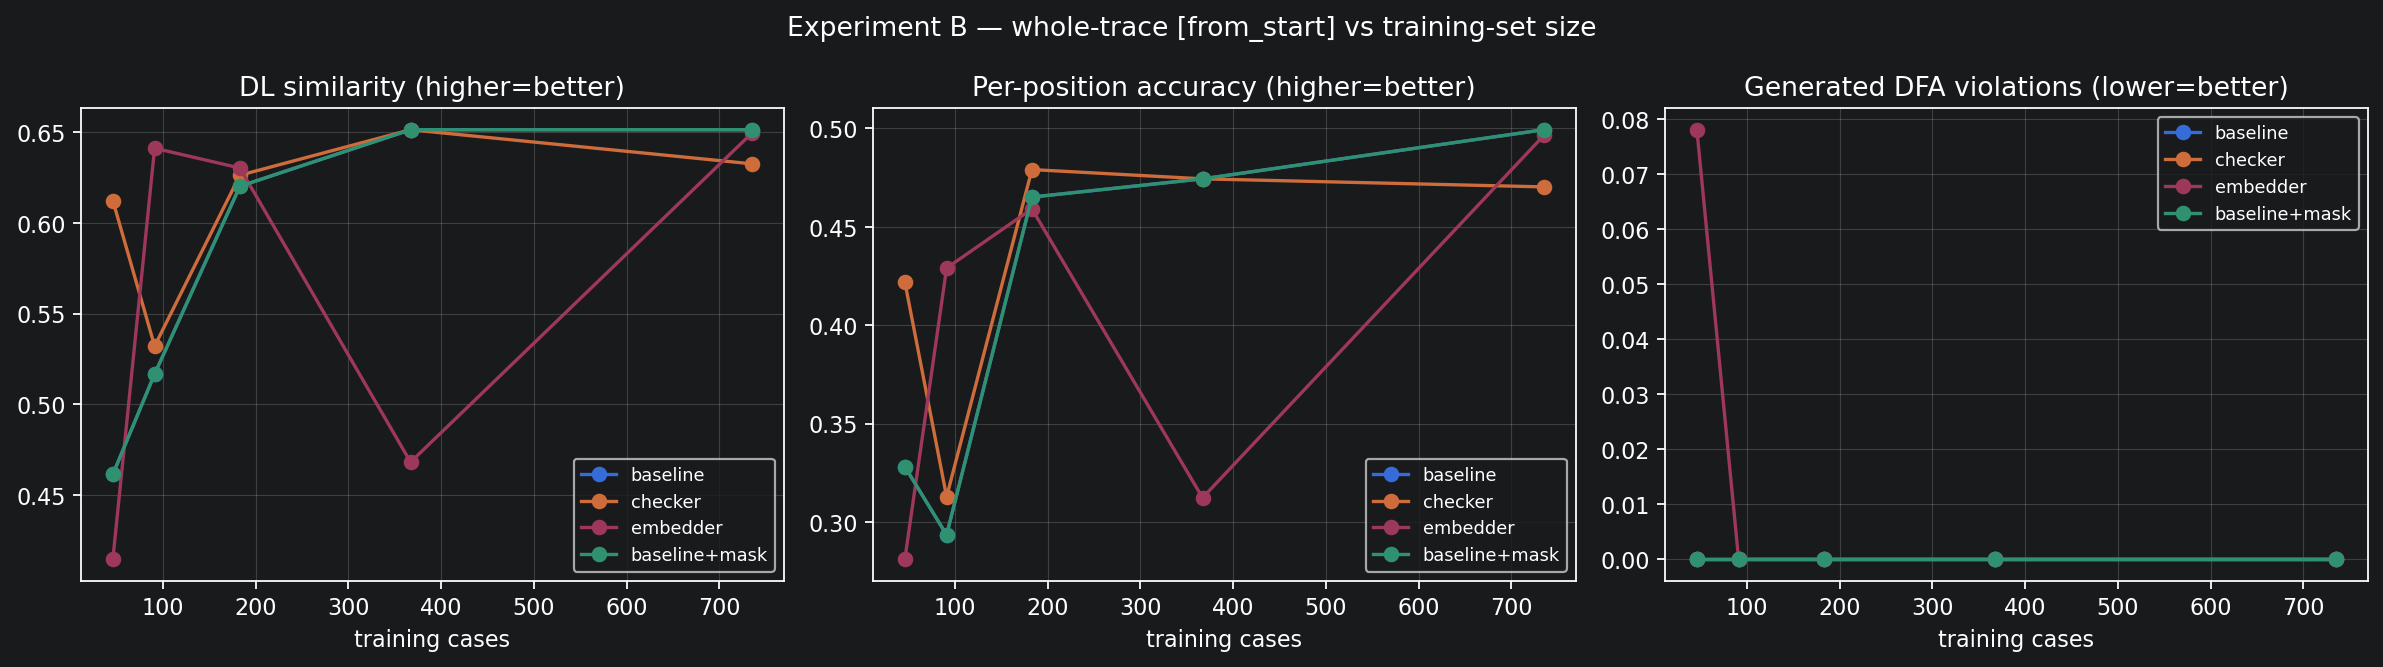

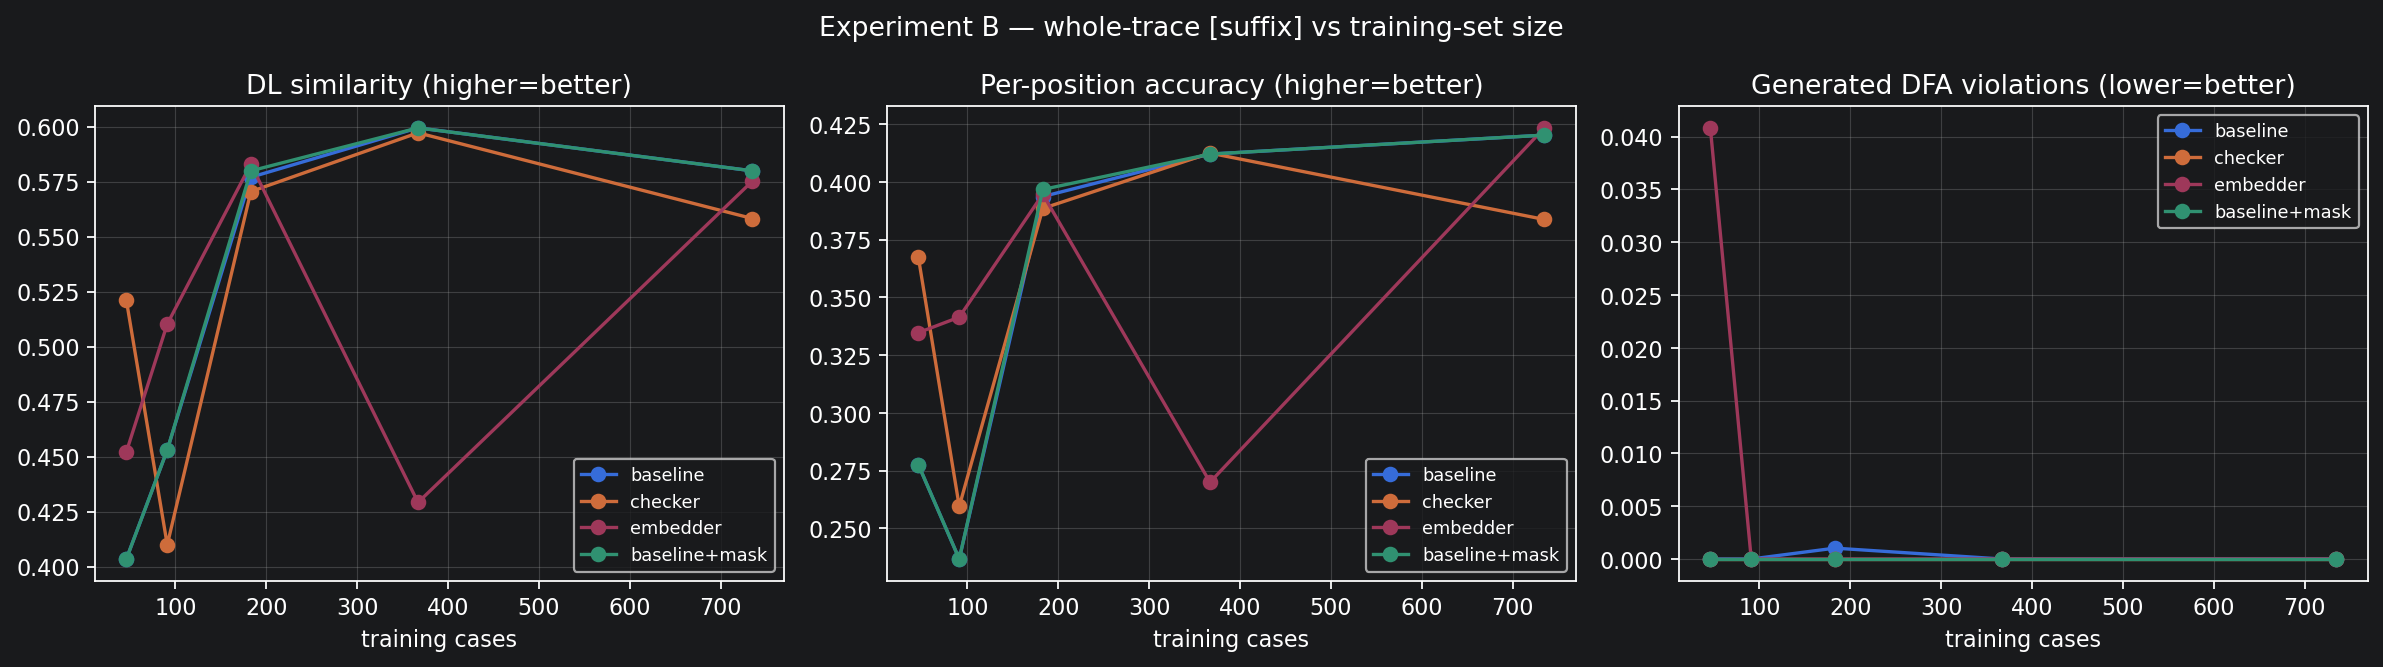

Verdict: best logic variant vs baseline (DL similarity), from_start:
  f=1.0   : baseline=0.6513  best=0.6513 (baseline)  d=+0.0000
  f=0.5   : baseline=0.6513  best=0.6513 (baseline)  d=+0.0000
  f=0.25  : baseline=0.6202  best=0.6303 (embedder)  d=+0.0101
  f=0.125 : baseline=0.5168  best=0.6412 (embedder)  d=+0.1244
  f=0.0625: baseline=0.4616  best=0.6123 (checker)  d=+0.1507


In [14]:
for setup in ("from_start", "suffix"):
    sub = wt_grid[wt_grid.setup == setup]
    path = OUTPUT_DIR / f"expB_curves_{setup}.png"
    plots.plot_fraction_curves(sub,
        ["dl_similarity", "activity_accuracy", "dfa_violation_rate"], path,
        mode_col="variant",
        titles={"dl_similarity": "DL similarity (higher=better)",
                "activity_accuracy": "Per-position accuracy (higher=better)",
                "dfa_violation_rate": "Generated DFA violations (lower=better)"},
        suptitle=f"Experiment B — whole-trace [{setup}] vs training-set size")
    display(Image(filename=str(path)))

print("Verdict: best logic variant vs baseline (DL similarity), from_start:")
sub = wt_grid[wt_grid.setup == "from_start"]
for fraction in sorted(sub.fraction.unique(), reverse=True):
    f = sub[sub.fraction == fraction]
    base = f[f.variant == "baseline"]["dl_similarity"].iloc[0]
    best_variant = f.loc[f["dl_similarity"].idxmax(), "variant"]
    best = f["dl_similarity"].max()
    print(f"  f={fraction:<6}: baseline={base:.4f}  best={best:.4f} "
          f"({best_variant})  d={best - base:+.4f}")

## 11. Conclusions

- **Single-step vs whole-trace.** Logic barely moves next-activity accuracy
  (Experiment A) because the baseline already absorbs local structure. The honest
  place to look for its value is the **whole predicted trace** (Experiment B),
  where errors compound.
- **Two mechanisms, different jobs.** *Output refinement* (`baseline+mask`)
  guarantees conformant generations with zero retraining (DFA violations → 0); the
  *logic-in-loss* models (checker/embedder) internalise structure and can help even
  the free-running rollout. The gap between them is the trade-off between
  training-time and inference-time knowledge.
- **Data regime matters.** Symbolic knowledge earns its keep most when data is
  scarce; with all 1050 cases the neural model learns the process on its own.

**Stated limitations.** No EOS token → length-conditioned generation (ordering, not
length, is judged); only the *precedence* LTLf template is mined; multiple
constraints are combined by averaging per-DFA distances (not a product automaton);
single seed. See `docs/IMPROVEMENTS.md` for how each could be lifted.

bpic 2013/2020, prendere i dataset, prendere un 10%/20/30 etc e li sporco e cambio la label. noise injection, logica dal dateset pulito e poi con il training sporco. Provare anche, estrarre petrinet. tools place transition e marking e matrice di adiacenza e per ogni nodo ho un place oppure una transition. eterogenous ggn, nel momento che dai un prefisto hai un marking. pallini sui place, nel momento va avanti nelle transition. provare con una petrinet e il marking novita.